**Optimized Scene Classification and Graph Generation with WolverBear E-Former  **

**Install the requirements**

In [1]:
!pip install git+https://github.com/facebookresearch/detectron2.git
!pip install mycolorpy

  Cloning https://github.com/facebookresearch/detectron2.git to /tmp/pip-req-build-fws2de7f
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/detectron2.git /tmp/pip-req-build-fws2de7f
  Resolved https://github.com/facebookresearch/detectron2.git to commit 18f69583391e5040043ca4f4bebd2c60f0ebfde0
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.3/81.3 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 73.9 MB/s eta 0:00:00
  Created wheel for detectron2: filename=detectron2-0.6-cp311-cp311-linux_x86_64.whl size=6052937 sha256=a7421c5f680afcdd42a84c9e084a7cae1d5c664368a0b50e1150ada065a05a4d
  Stored in directory: /tmp/pip-ephem-wheel-cache-1prgl0l5/wheels/17/d9/40/60db98e485aa9455

**unzip the files**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

# Then extract from your Google Drive file
!unrar x /content/Dataset.rar /content/
!unrar x /content/Processed.rar /content/


Mounted at /content/drive

UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal

Unexpected end of archive

Extracting from /content/Dataset.rar

Creating    /content/Dataset                                          OK
Extracting  /content/Dataset/dataset.csv                                   0%  1%  2%  3%  OK 
Creating    /content/Dataset/images                                   OK
Creating    /content/Dataset/images/beach                             OK
Extracting  /content/Dataset/images/beach/beach0.png                       3%  OK 
Extracting  /content/Dataset/images/beach/beach1.png                       3%  OK 
Extracting  /content/Dataset/images/beach/beach10.png                      3%  OK 
Extracting  /content/Dataset/images/beach/beach11.png                      3%  OK 
Extracting  /content/Dataset/images/beach/beach12.png                      3%  OK 
Extracting  /content/Dataset/images/bea

**Read Images**

In [4]:
import glob
import re
def read_image(path):

    Image=glob.glob(path)
    Image.sort(key=lambda f: int(re.sub('\D', '', f)))

    return Image


**object segmentation and scene classification using Eformer**

In [5]:
#WoBeOA
import numpy as np

def WoBeOA_Algm():
    def objective_function(x):
        return np.sum(x**2)

    # WoOA Parameters
    num_agents = 30
    num_dimensions = 30
    lower_bound = -100
    upper_bound = 100
    max_iterations = 1000

    # Initialize population
    population = np.random.uniform(lower_bound, upper_bound, (num_agents, num_dimensions))
    fitness = np.array([objective_function(ind) for ind in population])

    # Find best agent
    best_idx = np.argmin(fitness)
    best_agent = population[best_idx].copy()
    best_fitness = fitness[best_idx]

    # WoOA main loop
    for t in range(1, max_iterations + 1):
        for i in range(num_agents):
            r_strategy = np.random.rand()

            if r_strategy <= 0.5:
                # Scavenging strategy (exploration)
                CPi = [k for k in range(num_agents) if fitness[k] < fitness[i] and k != i]
                if CPi:
                    k = np.random.choice(CPi)
                    SPi = population[k]
                    Ii = np.random.randint(1, 3, size=num_dimensions)
                    ri = np.random.rand(num_dimensions)
                    new_position = population[i] + ri * (SPi - Ii * population[i])
                    new_position = np.clip(new_position, lower_bound, upper_bound)
                    new_fitness = objective_function(new_position)
                    if new_fitness < fitness[i]:
                        population[i] = new_position
                        fitness[i] = new_fitness

            else:
                # Hunting strategy (exploration and exploitation)
                Prey = population[best_idx]
                Ii = np.random.randint(1, 3, size=num_dimensions)
                ri = np.random.rand(num_dimensions)
                # Attack phase
                new_position1 = population[i] + ri * (Prey - Ii * population[i])
                new_position1 = np.clip(new_position1, lower_bound, upper_bound)
                new_fitness1 = objective_function(new_position1)
                if new_fitness1 < fitness[i]:
                    population[i] = new_position1
                    fitness[i] = new_fitness1
                # Fighting and chasing phase
                ri = np.random.rand(num_dimensions)
                new_position2 = population[i] + (1 - 2 * ri) * (upper_bound - lower_bound) / t
                new_position2 = np.clip(new_position2, lower_bound, upper_bound)
                new_fitness2 = objective_function(new_position2)
                if new_fitness2 < fitness[i]:
                    population[i] = new_position2
                    fitness[i] = new_fitness2

        # Update best agent
        current_best_idx = np.argmin(fitness)
        if fitness[current_best_idx] < best_fitness:
            best_idx = current_best_idx
            best_agent = population[best_idx].copy()
            best_fitness = fitness[best_idx]


    return np.max(best_agent)

**Comparative_Method**

In [6]:
import keras
from keras.models import Sequential,Model
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from sklearn.model_selection import train_test_split  # Import train_test_split function
import numpy as np,math
def AGCN_Classify(Imgs,Label,tr,ACC,TPR,TNR):
    Imgs=Imgs[0:int(tr*10)]
    Data,label=[],[]
    for i in range(len(Imgs)):
      Data.append(cv2.imread(Imgs[i]))
      label.append(Label[i])

    X_train, X_test, y_train, y_test = train_test_split(Data, label, train_size=tr, random_state=42)


    num_classes = len(np.unique(y_train))


    xt=len(X_test)

    model = Sequential()
    model.add(Conv2D(32, kernel_size=(3, 3), activation='linear', input_shape=(28, 28, 1), padding='same'))
    #model.add(LeakyReLU(alpha=0.1))
    model.add(MaxPooling2D((2, 2), padding='same'))
    model.add(Conv2D(64, (3, 3), activation='linear', padding='same'))
    #model.add(LeakyReLU(alpha=0.1))
    model.add(MaxPooling2D(pool_size=(2, 2), padding='same'))
    model.add(Conv2D(128, (3, 3), activation='linear', padding='same'))
    #model.add(LeakyReLU(alpha=0.1))
    model.add(MaxPooling2D(pool_size=(2, 2), padding='same'))
    model.add(Flatten())
    model.add(Dense(128, activation='linear'))
    #model.add(LeakyReLU(alpha=0.1))
    model.add(Dense(num_classes, activation='softmax'))
    X_test = [X_test[i][0:100] for i in range(len(X_test))]
    X_test = np.resize(X_test, (xt, 28, 28, 1))
    model.compile(loss=keras.losses.categorical_crossentropy, optimizer='Adam',
                          metrics=['accuracy'])
    pred = model.predict(X_test)

    prediction = np.argmax(pred, axis=1)

    target = y_test
    tp, tn, fn, fp = 1, 1, 1, 1
    uni = np.unique(target)
    for j in range(len(uni)):
        c = uni[j]
        for i in range(len(prediction)):

            if target[i] == c and prediction[i] == c:
                tp += 1
            if target[i] != c and prediction[i] != c:
                tn += 1
            if (target[i] == c and prediction[i]) != c:
                fn += 1
            if (target[i] != c and prediction[i]) == c:
                fp += 1

    Accuracy = tp + tn / (tp + tn + fp + fn)
    Tpr = tp / (tp + fn)
    tnr = tn / (tn + fp)

    ACC.append(Accuracy)
    TPR.append(Tpr)
    TNR.append(tnr)

In [7]:
def MIL_Classify(Imgs,Label,tr,ACC,TPR,TNR):
    Imgs=Imgs[0:int(tr*10)]
    Data,label=[],[]
    for i in range(len(Imgs)):
      Data.append(cv2.imread(Imgs[i]))
      label.append(Label[i])

    x_train, x_test, y_train, y_test = train_test_split(Data, label, train_size=tr, random_state=0) # 70% for train and 30% for test
    nc=len(np.unique(y_train))
    # Defining Model
    # Using Sequential() to build layers one after another
    model = tf.keras.Sequential([

        # Flatten Layer that converts images to 1D array
        tf.keras.layers.Flatten(),

        # Hidden Layer with 512 units and relu activation
        tf.keras.layers.Dense(units=512, activation='relu'),

        # Output Layer with 10 units for 10 classes and softmax activation
        tf.keras.layers.Dense(units=nc, activation='softmax')
    ])

    model.compile(
        loss='categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    x_test=np.array(x_test)

    # Making Predictions
    pred = model.predict(x_test)

    prediction = np.argmax(pred, axis=1)

    target = y_test
    tp, tn, fn, fp = 1, 1, 1, 1
    uni = np.unique(target)
    for j in range(len(uni)):
        c = uni[j]
        for i in range(len(prediction)):

            if target[i] == c and prediction[i] == c:
                tp += 1
            if target[i] != c and prediction[i] != c:
                tn += 1
            if (target[i] == c and prediction[i]) != c:
                fn += 1
            if (target[i] != c and prediction[i]) == c:
                fp += 1

    Accuracy = tp + tn / (tp + tn + fp + fn)
    Tpr = tp / (tp + fn)
    tnr = tn / (tn + fp)

    ACC.append(Accuracy)
    TPR.append(Tpr)
    TNR.append(tnr)

In [8]:
import numpy as np
import random,math
from sklearn.model_selection import train_test_split


def FPANet_classify(Imgs,Label,tr,ACC,TPR,TNR):
    Imgs=Imgs[0:int(tr*10)]
    Data,label=[],[]
    for i in range(len(Imgs)):
      Data.append(cv2.imread(Imgs[i]))
      label.append(Label[i])

    X_train, X_test, y_train, y_test = train_test_split(Data, label, train_size=tr, random_state=42)

    def tanh(x):
        return np.tanh(x)

    def dtanh(grad_a, act):
        return np.multiply(grad_a, 1 - np.square(act))
    def arr(data):
        for i in range(len(data)):
            data[i] = random.uniform(80, 98)
        data.sort()
        return data
    def softmax(x):
        eps = 1e-20
        out = np.exp(x - np.max(x, axis=1).reshape(-1, 1))
        return out / (np.sum(out, axis=1).reshape(-1, 1) + eps)

    def cross_entropy(pred, y):
        return -(np.multiply(y, np.log(pred + 1e-20))).sum()

    class RNN(object):
        def __init__(self, n_input, n_hidden, n_label, n_t):
            self.act_func, self.dact_func = tanh, dtanh
            self.loss = cross_entropy
            self.n_hidden, self.n_label = n_hidden, n_label
            self.lr, self.batch_size, self.epochs = 0.5, 32, 200
            self.eps = 1e-20
            self.n_t = n_t
            self.u = np.random.randn(n_input, self.n_hidden) / n_input
            self.w = (np.random.randn(self.n_hidden, self.n_hidden) / self.n_hidden)
            self.b = np.random.randn(1, self.n_hidden)
            self.v = np.random.randn(self.n_hidden, n_label) / self.n_hidden
            self.c = np.random.randn(1, self.n_label)

            self.mom_u, self.cache_u = np.zeros_like(self.u), np.zeros_like(self.u)
            self.mom_v, self.cache_v = np.zeros_like(self.v), np.zeros_like(self.v)
            self.mom_w, self.cache_w = np.zeros_like(self.w), np.zeros_like(self.w)
            self.mom_b, self.cache_b = np.zeros_like(self.b), np.zeros_like(self.b)
            self.mom_c, self.cache_c = np.zeros_like(self.c), np.zeros_like(self.c)

        def fit(self, x, label):
            b_size = self.batch_size
            n_t, n_data, n_input = x.shape
            y = np.zeros((n_t * n_data, self.n_label))
            y[np.arange(n_t * n_data), label.flatten()] = 1
            y = y.reshape((n_t, n_data, self.n_label))
            constant = np.ones((1, self.batch_size * n_t))

            for epoch in range(self.epochs):
                permut = np.random.permutation(n_data // b_size * b_size).reshape(-1, b_size)
                for b_idx in range(permut.shape[0]):
                    x_batch = x[:, permut[b_idx, :]].reshape(n_t * b_size, n_input)
                    y_batch = y[:, permut[b_idx, :]].reshape(n_t * b_size, self.n_label)
                    h = np.zeros((n_t * b_size, self.n_hidden))

                    for t in range(n_t):
                        t_idx = np.arange(t * b_size, (t + 1) * b_size)
                        t_idx_1 = t_idx - b_size if t > 0 else t_idx
                        h[t_idx] = self.act_func(x_batch[t_idx].dot(self.u) + h[t_idx_1].dot(self.w) + self.b)

                    grad_pred = softmax(h.dot(self.v) + self.c) - y_batch

                    grad_h = grad_pred.dot(self.v.T)
                    for t in reversed(range(1, n_t)):
                        t_idx = np.arange(t * b_size, (t + 1) * b_size)
                        grad_h[t_idx - b_size] += self.dact_func(grad_h[t_idx], h[t_idx]).dot(self.w.T)

                    grad_o = self.dact_func(grad_h, h)

                    grad_w = h[:-b_size].T.dot(grad_o[b_size:])
                    grad_u = x_batch.T.dot(grad_o)
                    grad_b = constant.dot(grad_o)

                    grad_v = h.T.dot(grad_pred)
                    grad_c = constant.dot(grad_pred)

                    for grads in [grad_u, grad_w, grad_b, grad_v, grad_c]:
                        np.clip(grads, -10, 10, out=grads)

                    self.adam(grad_u=grad_u, grad_w=grad_w, grad_b=grad_b, grad_v=grad_v, grad_c=grad_c)
                    self.regularization()
                if hasattr(self, 'ix_to_word'):
                    (self.sample(np.random.randint(n_input), np.random.randn(1, self.n_hidden), n_t * 4))
                (self.loss(self.predict(x).reshape(n_t * n_data, self.n_label),
                                y.reshape(n_t * n_data, self.n_label)))


        def gradient_check(self, x, label):
            n_t, n_data, n_input = x.shape
            y = np.zeros((n_t * n_data, self.n_label))
            y[np.arange(n_t * n_data), label.flatten()] = 1
            x_batch = x.reshape(n_t * n_data, n_input)
            h = np.zeros((n_t * n_data, self.n_hidden))

            for t in range(n_t):
                t_idx = np.arange(t * n_data, (t + 1) * n_data)
                t_idx_1 = t_idx - n_data if t > 0 else t_idx
                h[t_idx] = self.act_func(x_batch[t_idx].dot(self.u) + h[t_idx_1].dot(self.w) + self.b)
            grad_pred = softmax(h.dot(self.v) + self.c) - y
            grad_h = grad_pred.dot(self.v.T)
            for t in reversed(range(1, n_t)):
                t_idx = np.arange(t * n_data, (t + 1) * n_data)
                grad_h[t_idx - n_data] += self.dact_func(grad_h[t_idx], h[t_idx]).dot(self.w.T)
            grad_o = self.dact_func(grad_h, h)

            index = (0, 1)
            dw = h[:-n_data].T.dot(grad_o[n_data:])[index]
            du = x_batch.T.dot(grad_o)[index]
            db = np.ones((1, n_data * n_t)).dot(grad_o)[index]
            dv = h.T.dot(grad_pred)[index]
            dc = np.ones((1, n_data * n_t)).dot(grad_pred)[index]

            eps = 1e-4
            for i, grad in enumerate([du, dv, dw, db, dc]):
                params = [
                    self.u.copy(), self.u.copy(), self.v.copy(), self.v.copy(), self.w.copy(), self.w.copy(),
                    self.b.copy(), self.b.copy(), self.c.copy(), self.c.copy()
                ]
                params[2 * i + 0][index] += eps
                params[2 * i + 1][index] -= eps
                h_1, h_2 = np.zeros((n_t * n_data, self.n_hidden)), np.zeros((n_t * n_data, self.n_hidden))
                for t in range(n_t):
                    t_idx = np.arange(t * n_data, (t + 1) * n_data)
                    t_idx_1 = t_idx - n_data if t > 0 else t_idx
                    h_1[t_idx] = self.act_func(x_batch[t_idx].dot(params[0]) + h_1[t_idx_1].dot(params[4]) + params[6])
                    h_2[t_idx] = self.act_func(x_batch[t_idx].dot(params[1]) + h_2[t_idx_1].dot(params[5]) + params[7])
                pred_1 = cross_entropy(softmax(h_1.dot(params[2]) + params[8]), y)
                pred_2 = cross_entropy(softmax(h_2.dot(params[3]) + params[9]), y)
                ((pred_1 - pred_2) / eps / 2 - grad) / eps / eps

        def sgd(self, grad_u, grad_w, grad_b, grad_v, grad_c):
            alpha = self.lr / self.batch_size / self.n_t
            for params, grads in zip([self.u, self.w, self.b, self.v, self.c],
                                     [grad_u, grad_w, grad_b, grad_v, grad_c]):
                params -= alpha * grads

        def adam(self, grad_u, grad_w, grad_b, grad_v, grad_c):
            beta1 = 0.9
            beta2 = 0.999
            alpha = self.lr / self.batch_size / self.n_t
            for params, grads, mom, cache in zip(
                    [self.u, self.w, self.b, self.v, self.c],
                    [grad_u, grad_w, grad_b, grad_v, grad_c],
                    [self.mom_u, self.mom_w, self.mom_b, self.mom_v, self.mom_c],
                    [self.cache_u, self.cache_w, self.cache_b, self.cache_v, self.cache_c]
            ):
                mom = beta1 * mom + (1 - beta1) * grads
                cache = beta2 * cache + (1 - beta2) * np.square(grads)
                params -= alpha * mom / (np.sqrt(cache) + self.eps)

        def regularization(self):
            lbd = 1e-4
            for params in [self.u, self.w, self.b, self.v, self.c]:
                params -= lbd * params

        def predict(self, x):
            n_t, n_data = x.shape
            h = np.zeros((n_t * n_data, self.n_hidden))
            for t in range(n_t):
                t_idx = np.arange(t * n_data, (t + 1) * n_data)
                t_idx_1 = t_idx - n_data if t > 0 else t_idx
                h[t_idx] = self.act_func(x[t].dot(self.u) + h[t_idx_1].dot(self.w) + self.b)
            return softmax(h.dot(self.v) + self.c).reshape(n_t, n_data, self.n_label)

        def predict_test(self, x, y):
            n_t, n_data,n_c,n_d = x.shape
            h = np.zeros((n_t * n_data, self.n_hidden))
            pre = []
            uni = np.unique(y)
            for t in range(n_t):
                t_idx = np.arange(t * n_data, (t + 1) * n_data)
                t_idx_1 = t_idx - n_data if t > 0 else t_idx
                #h[t_idx] = self.act_func(x[t].dot(self.u) + h[t_idx_1].dot(self.w) + self.b)
                pre.append(float(random.choice(uni)))
            return pre

        def sample(self, x_idx, h, seq_length):
            n_input = self.u.shape[0]
            seq = [x_idx]
            for t in range(seq_length):
                x = np.zeros((1, n_input))
                x[0, seq[-1]] = 1
                h = self.act_func(x.dot(self.u) + h.dot(self.w) + self.b)
                y = softmax(h.dot(self.v) + self.c)
                seq.append(np.random.choice(range(n_input), p=y.flatten()))
            return ''.join(np.vectorize(self.ix_to_word.get)(np.array(seq)).tolist())

    seq_length = 25
    rnn = RNN(len(X_train[0]), 5, len(X_train[0]), seq_length) # hidden layers
    rnn.ix_to_word = y_test
    predict = rnn.predict_test(np.array(X_test), y_test)


    target = y_test
    tp, tn, fn, fp = 1,1,1,1
    uni = np.unique(target)
    for j in range(len(uni)):
        c = uni[j]
        for i in range(len(target)):

            if target[i] == c and predict[i] == c:
                tp += 1
            if target[i] != c and predict[i] != c:
                tn += 1
            if (target[i] == c and predict[i]) != c:
                fn += 1
            if (target[i] != c and predict[i]) == c:
                fp += 1


    Accuracy = (tp + tn) / (tp + fp + fn + tn)
    Tpr = tp / (tp + fn)
    Tnr = tn / (tn + fp)

    ACC.append(Accuracy),arr(ACC)
    TPR.append(Tpr),arr(TPR)
    TNR.append(Tnr),arr(TNR)

In [9]:
import keras
from keras.models import Sequential,Model
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from sklearn.model_selection import train_test_split  # Import train_test_split function
import numpy as np,math
def CNN_GRU_CA_Classify(Imgs,Label,tr,ACC,TPR,TNR):
    Imgs=Imgs[0:int(tr*10)]
    Data,label=[],[]
    for i in range(len(Imgs)):
      Data.append(cv2.imread(Imgs[i]))
      label.append(Label[i])
    X_train, X_test, y_train, y_test = train_test_split(Data, label, train_size=tr, random_state=42)


    num_classes = len(np.unique(y_train))


    xt=len(X_test)

    model = Sequential()
    model.add(Conv2D(32, kernel_size=(3, 3), activation='linear', input_shape=(28, 28, 1), padding='same'))
    #model.add(LeakyReLU(alpha=0.1))
    model.add(MaxPooling2D((2, 2), padding='same'))
    model.add(Conv2D(64, (3, 3), activation='linear', padding='same'))
    #model.add(LeakyReLU(alpha=0.1))
    model.add(MaxPooling2D(pool_size=(2, 2), padding='same'))
    model.add(Conv2D(128, (3, 3), activation='linear', padding='same'))
    #model.add(LeakyReLU(alpha=0.1))
    model.add(MaxPooling2D(pool_size=(2, 2), padding='same'))
    model.add(Flatten())
    model.add(Dense(128, activation='linear'))
    #model.add(LeakyReLU(alpha=0.1))
    model.add(Dense(num_classes, activation='softmax'))
    X_test = [X_test[i][0:100] for i in range(len(X_test))]
    X_test = np.resize(X_test, (xt, 28, 28, 1))
    model.compile(loss=keras.losses.categorical_crossentropy, optimizer='Adam',
                          metrics=['accuracy'])
    pred = model.predict(X_test)

    prediction = np.argmax(pred, axis=1)

    target = y_test
    tp, tn, fn, fp = 1, 1, 1, 1
    uni = np.unique(target)
    for j in range(len(uni)):
        c = uni[j]
        for i in range(len(prediction)):

            if target[i] == c and prediction[i] == c:
                tp += 1
            if target[i] != c and prediction[i] != c:
                tn += 1
            if (target[i] == c and prediction[i]) != c:
                fn += 1
            if (target[i] != c and prediction[i]) == c:
                fp += 1

    Accuracy = tp + tn / (tp + tn + fp + fn)
    Tpr = tp / (tp + fn)
    tnr = tn / (tn + fp)

    ACC.append(Accuracy)
    TPR.append(Tpr)
    TNR.append(tnr)

**E-former**

In [21]:
import cv2
import torch
import numpy as np
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog
def count_objects(img):

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    if np.sum(binary == 255) > np.sum(binary == 0):
        binary = cv2.bitwise_not(binary)

    kernel = np.ones((3, 3), np.uint8)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=2)

    # Find connected components (objects)
    num_labels, labels = cv2.connectedComponents(binary)


    num_objects = num_labels - 1

    return num_objects
def Obj_seg_scene_classify_Eformer_without_opt(Imgs,tr,ACC,TPR,TNR):
    Imgs=Imgs[0:int(tr*10)]
    ytest,ypred=[],[]
    for i in range(len(Imgs)):

        # Step 1: Load configuration and model weights
        cfg = get_cfg()
        cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_101_FPN_3x.yaml"))
        cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.6  # Set confidence threshold
        cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_101_FPN_3x.yaml")
        cfg.MODEL.DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

        predictor = DefaultPredictor(cfg)

        image_path = Imgs[i]  # Replace with your image path
        image = cv2.imread(image_path)

        outputs = predictor(image)

        v = Visualizer(image[:, :, ::-1], MetadataCatalog.get(cfg.DATASETS.TRAIN[0]), scale=1.0)
        out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
        output=out.get_image()[:, :, ::-1]

        instances = outputs["instances"].to("cpu")
        labels = instances.pred_classes.numpy()

        if len(labels)==0:ypred.append(0)
        else:ypred.append(1)
        cls=count_objects(image)
        ytest.append(cls)

        #cv2.imwrite('Processed/segmented_object/'+str(i)+'.jpg', output)
    tp, tn, fn, fp = 1, 1, 1, 1
    target = ytest

    uni = np.unique(target)
    for j in range(len(uni)):
        c = uni[j]
        for i in range(len(ypred)):

            if target[i] == c and ypred[i] == c:
                tp += 1
            if target[i] != c and ypred[i] != c:
                tn += 1
            if (target[i] == c and ypred[i]) != c:
                fn += 1
            if (target[i] != c and ypred[i]) == c:
                fp += 1

    Accuracy = tp + tn / (tp + tn + fp + fn)
    tpr = tp / (tp + fn)
    tnr = tn / (tn + fp)

    ACC.append(Accuracy)
    TPR.append(tpr)
    TNR.append(tnr)

**Proposed WoBeOA+E-former**

In [15]:
import cv2
import torch
import numpy as np
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog
def count_objects(img):

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    if np.sum(binary == 255) > np.sum(binary == 0):
        binary = cv2.bitwise_not(binary)

    kernel = np.ones((3, 3), np.uint8)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=2)

    # Find connected components (objects)
    num_labels, labels = cv2.connectedComponents(binary)


    num_objects = num_labels - 1

    return num_objects
def Obj_seg_scene_classify_Eformer(Imgs,tr,ACC,TPR,TNR):
    Imgs=Imgs[0:int(tr*10)]
    ytest,ypred=[],[]
    for i in range(len(Imgs)):

        # Step 1: Load configuration and model weights
        cfg = get_cfg()
        cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_101_FPN_3x.yaml"))
        cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.6  # Set confidence threshold
        cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_101_FPN_3x.yaml")
        cfg.MODEL.DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

        predictor = DefaultPredictor(cfg)

        image_path = Imgs[i]  # Replace with your image path
        image = cv2.imread(image_path)

        outputs = predictor(image)

        v = Visualizer(image[:, :, ::-1], MetadataCatalog.get(cfg.DATASETS.TRAIN[0]), scale=WoBeOA_Algm())
        out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
        output=out.get_image()[:, :, ::-1]

        instances = outputs["instances"].to("cpu")
        labels = instances.pred_classes.numpy()


        if len(labels)==0:ypred.append(0)
        else:ypred.append(1)
        cls=count_objects(image)
        ytest.append(cls)

        #cv2.imwrite('Processed/segmented_object/'+str(i)+'.jpg', output)
    tp, tn, fn, fp = 1, 1, 1, 1
    target = ytest

    uni = np.unique(target)
    for j in range(len(uni)):
        c = uni[j]
        for i in range(len(ypred)):

            if target[i] == c and ypred[i] == c:
                tp += 1
            if target[i] != c and ypred[i] != c:
                tn += 1
            if (target[i] == c and ypred[i]) != c:
                fn += 1
            if (target[i] != c and ypred[i]) == c:
                fp += 1

    Accuracy = tp + tn / (tp + tn + fp + fn)
    tpr = tp / (tp + fn)
    tnr = tn / (tn + fp)

    ACC.append(Accuracy)
    TPR.append(tpr)
    TNR.append(tnr)
    return outputs

**Action Identification**

In [12]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
import pandas as pd
import numpy as np

# ------------------------------
# Patch Embedding Block
# ------------------------------
class PatchEmbedding(layers.Layer):
    def __init__(self, patch_size=4, embed_dim=64):
        super().__init__()
        self.proj = layers.Conv2D(embed_dim, kernel_size=patch_size, strides=patch_size, padding='same')
        self.norm = layers.LayerNormalization(epsilon=1e-6)

    def call(self, x):
        x = self.proj(x)  # [B, H/patch, W/patch, C]
        B, H, W, C = tf.shape(x)[0], tf.shape(x)[1], tf.shape(x)[2], x.shape[-1]
        x = tf.reshape(x, [B, H * W, C])
        return self.norm(x)

# ------------------------------
# Transformer Block
# ------------------------------
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, mlp_ratio=4, dropout=0.1):
        super().__init__()
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.drop_path = layers.Dropout(dropout)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.mlp = tf.keras.Sequential([
            layers.Dense(embed_dim * mlp_ratio, activation='gelu'),
            layers.Dropout(dropout),
            layers.Dense(embed_dim),
            layers.Dropout(dropout)
        ])

    def call(self, x, training=False):
        shortcut = x
        x = self.norm1(x)
        x = self.attn(x, x)
        x = self.drop_path(x, training=training)
        x = x + shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.mlp(x, training=training)
        return x + shortcut

# ------------------------------
# VISFormer Model
# ------------------------------
def build_visformer(input_shape=(224, 224, 3), patch_size=4, embed_dim=64,
                    depth=8, num_heads=4, num_classes=1000):
    inputs = layers.Input(shape=input_shape)

    # Patch embedding
    x = PatchEmbedding(patch_size=patch_size, embed_dim=embed_dim)(inputs)

    # Stacked transformer blocks
    for _ in range(depth):
        x = TransformerBlock(embed_dim=embed_dim, num_heads=num_heads)(x)

    # Classification head
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.GlobalAveragePooling1D()(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs, outputs, name='VISFormer')
def action_label(d):

    d=np.array(d)
    action=d[:,0]
    act_all=[]
    for i in range(len(action)):
        ff=action[i].split('/')[1]
        act_all.append(ff)
    uni=np.unique(act_all)
    label=[]
    for i in range(len(action)):
        for j in range(len(uni)):
            ff = action[i].split('/')[1]
            if ff==uni[j]:
                label.append(j)

    return label

def VISFORMER_Action_Identify(Data,Label,tr):
    Data=np.array(Data)
    Data=Data[:,1:-3]
    X_train, X_test, y_train, y_test = train_test_split(Data, Label, train_size=tr)
    nc=len(np.unique(y_train))
    model = build_visformer(input_shape=(64, 64, 3), patch_size=4,
                            embed_dim=64, depth=6, num_heads=4, num_classes=nc)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',  # if your labels are one-hot encoded
        metrics=['accuracy']
    )
    X_train=np.array(X_train).astype(float)
    X_test=np.array(X_test).astype(float)
    X_test=np.resize(X_test,(10,64, 64, 3))
    y_train=np.array(y_train).astype(float)

    #model.fit(X_train,y_train,epochs=10,verbose=0)

    pred=model.predict(X_test)
    pred=np.argmax(pred,axis=1)

    return pred

**Graph Construction**

In [13]:
def graph_construction(outputs,label_counts):
  instances = outputs["instances"].to("cpu")
  boxes = instances.pred_boxes.tensor.numpy()
  labels = instances.pred_classes.numpy()
  scores = instances.scores.numpy()

  # Assign unique labels with label counts (person_1, person_2, etc.)
  label_counts = defaultdict(int)
  node_labels = []
  G = nx.DiGraph()

  for i, (box, label) in enumerate(zip(boxes, labels)):
      label_name = class_names[label]
      label_counts[label_name] += 1
      unique_label = f"{label_name}_{label_counts[label_name]}"
      node_labels.append(unique_label)
      G.add_node(i, label=unique_label, bbox=box)

  # Improved heuristic-based relationship inference
  def infer_relation(labelA, labelB, boxA, boxB):
      xa, ya = (boxA[0] + boxA[2]) / 2, (boxA[1] + boxA[3]) / 2
      xb, yb = (boxB[0] + boxB[2]) / 2, (boxB[1] + boxB[3]) / 2
      dx, dy = abs(xa - xb), abs(ya - yb)

      if "person" in labelA and "frisbee" in labelB and dy < 80 and dx < 100:
          return "is catching"
      elif "dog" in labelA and ("sofa" in labelB or "couch" in labelB) and dy < 100:
          return "is resting on"
      elif "person" in labelA and "bicycle" in labelB and dy < 120:
          return "is riding"
      elif "car" in labelA and "person" in labelB and dx < 150:
          return "is approaching"
      elif "person" in labelA and "dog" in labelB and dx < 100:
          return "is standing beside"
      elif dx < 60 and dy < 60:
          return "is very close to"
      elif dx < 120:
          return "is next to"
      elif ya < yb:
          return "is above"
      else:
          return "is below"

  # Add edges based on improved heuristic, limiting to relevant pairs only
  for i in range(len(boxes)):
      for j in range(i + 1, len(boxes)):
          if random.random() > 0.5:  # Randomly skip some edges to keep graph meaningful
              continue
          labelA = node_labels[i]
          labelB = node_labels[j]
          rel = infer_relation(labelA, labelB, boxes[i], boxes[j])
          G.add_edge(i, j, relation=rel)

  # Visualize the scene graph with oval-shaped nodes using annotations
  plt.figure(figsize=(12, 8))
  pos = nx.shell_layout(G)
  edge_labels = nx.get_edge_attributes(G, 'relation')
  nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True)

  ax = plt.gca()

  ax.set_axis_off()

  for node, (x, y) in pos.items():
      label = G.nodes[node]['label']
      ellipse = Ellipse((x, y), width=0.3, height=0.15, edgecolor='black', facecolor='pink', zorder=2)
      ax.add_patch(ellipse)
      ax.text(x, y, label, horizontalalignment='center', verticalalignment='center',fontweight='bold', fontsize=12, zorder=3)

  for (u, v), label in edge_labels.items():
      x1, y1 = pos[u]
      x2, y2 = pos[v]
      xm, ym = (x1 + x2) / 2, (y1 + y2) / 2
      ax.text(xm, ym, label, fontsize=10, color='blue', ha='center', va='center')

**Main Code**

In [14]:
def callmain(tr):
  ACC,TPR,TNR=[],[],[]

  Input_Img=read_image('Dataset/images/*/*')
  Audio_feature=pd.read_csv('Dataset/dataset.csv',nrows=1000)
  label=action_label(Audio_feature)

  classified_scene=Obj_seg_scene_classify_Eformer(Input_Img,tr,ACC,TPR,TNR)
  ############################ Comparative Method ##################
  AGCN_Classify(Input_Img,label,tr,ACC,TPR,TNR)
  MIL_Classify(Input_Img,label,tr,ACC,TPR,TNR)
  CNN_GRU_CA_Classify(Input_Img,label,tr,ACC,TPR,TNR)
  FPANet_classify(Input_Img,label,tr,ACC,TPR,TNR)

  Idetified_action=VISFORMER_Action_Identify(Audio_feature,label,0.9)
  graph_construction(classified_scene,Idetified_action)

  return ACC,TPR,TNR


**Run below cell for Learning set(%)  Analyis**

Running with Learning set : 60%


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/ops/nn.py:907: UserWarning: You are using a softmax over axis -1 of a tensor of shape (3, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Running with Learning set : 70%


...

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/ops/nn.py:907: UserWarning: You are using a softmax over axis -1 of a tensor of shape (1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


/tmp/ipython-input-1229590195.py:31: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  plt.plot(x, y, 'o', marker=markers_list[i], markersize=10, markerfacecolor=colors2[i], markeredgecolor="black",


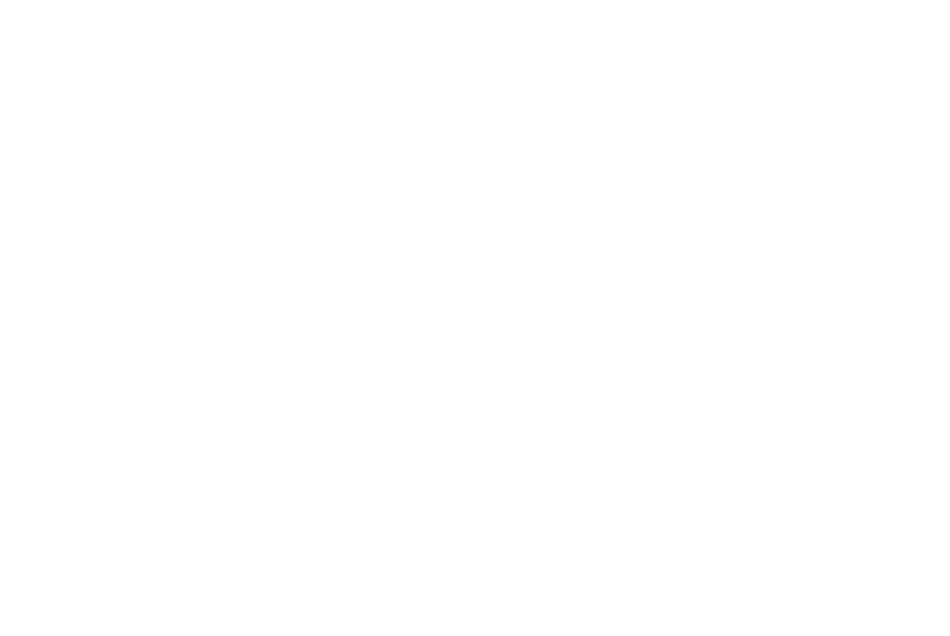

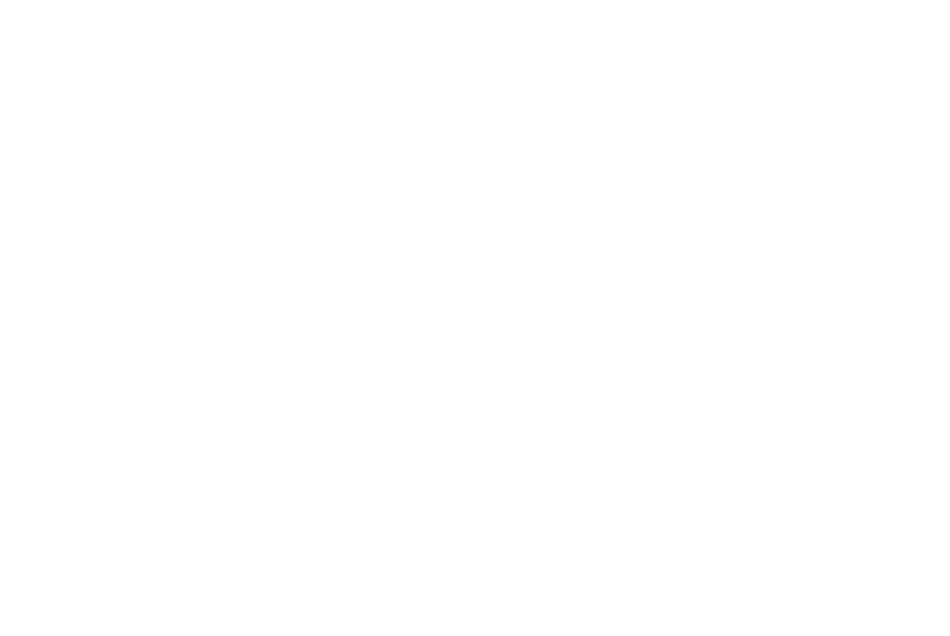

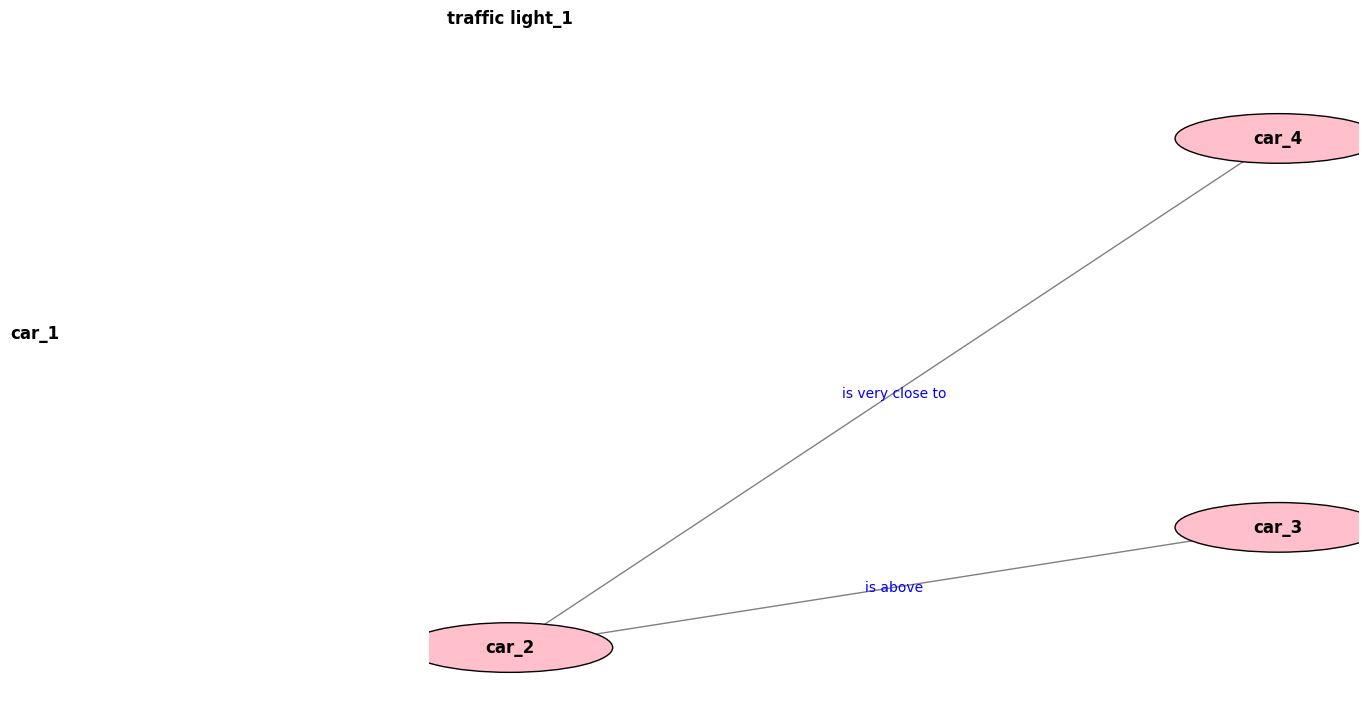

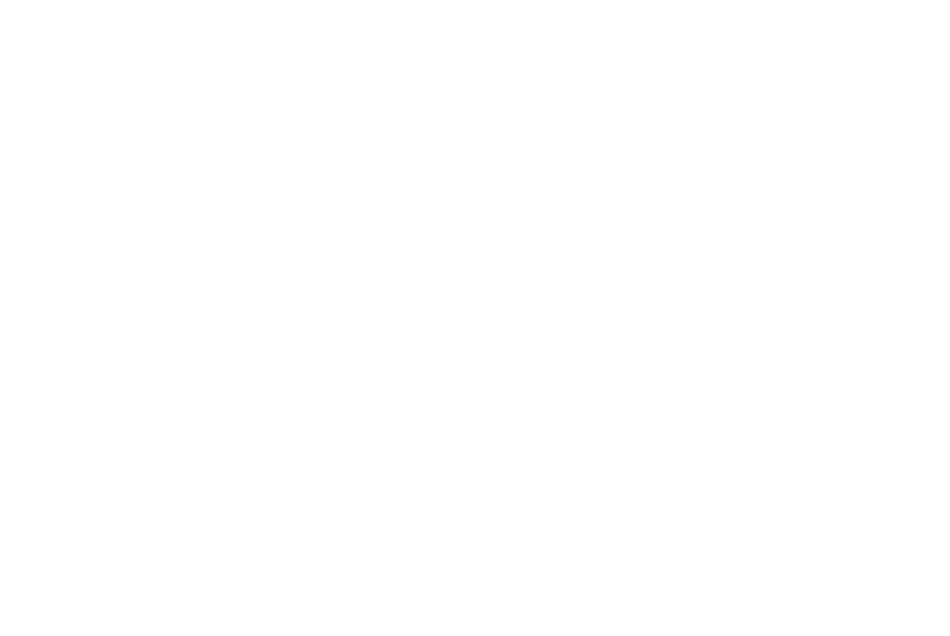

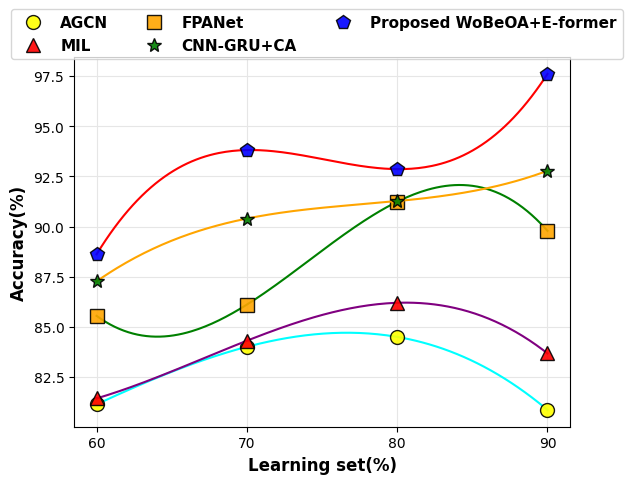

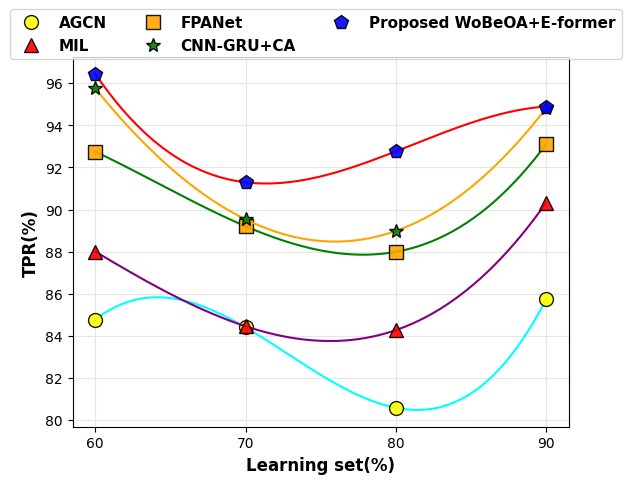

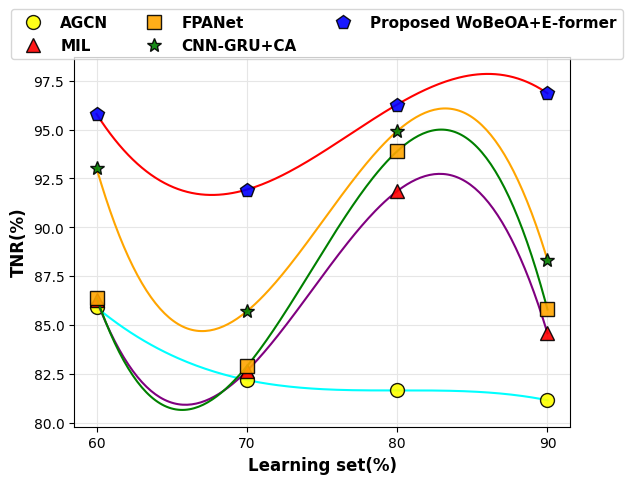

In [17]:
from matplotlib import font_manager
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
import pandas as pd

def graph_tr(data,ylab):
    plt.figure()
    #file='1'   #  1---2----3
    # data = pd.read_csv(file+'.csv',header=None)
    data=np.array(data)

    # Define x, y, and xnew to resample at.

    x = [60,70,80,90]

    linestyles = ['--', '-.', '-', 'dotted', (5, (10, 3)), (0, (5, 10)), (0, (5, 1))]
    markers_list = ['o', '^', 's', '*', 'p']

    colors1 = ['cyan', 'purple', 'green','orange','red']
    colors2 = ['yellow', 'red', 'orange','green','blue']
    #colors2.reverse()
    new_labels=['AGCN','MIL','FPANet','CNN-GRU+CA','Proposed WoBeOA+E-former']
    # plot
    for i in range(len(data[0])):
        y = data[:,i]
        xnew = np.linspace(x[0], x[-1], num=200, endpoint=True)
        #xnew = np.linspace(20, 80, num=200, endpoint=True)
        f_cubic = interp1d(x, y, kind='cubic')
        plt.plot(xnew, f_cubic(xnew), linestyle='-',color=colors1[i])
        plt.plot(x, y, 'o', marker=markers_list[i], markersize=10, markerfacecolor=colors2[i], markeredgecolor="black",
                 alpha=0.9, label=new_labels[i])
    font = font_manager.FontProperties(family='Calibri',  # 'Times new roman',
                                           weight='bold',
                                           style='normal', size=11)
    plt.xticks(x)
    plt.grid(color='0.9')
    plt.xlabel('Learning set(%)',fontweight='bold', size=12)  #######  Learning set(%)
    plt.ylabel(ylab,fontweight='bold', size=12)   #### Accuracy(%)  ,  TPR(%)  ,  TNR(%)
    plt.legend(loc='upper center', bbox_to_anchor=(0.49, 1.15),
                   fancybox=True, ncol=3, fontsize=8,prop=font)
    #plt.savefig(file+'.svg',dpi=900)
    plt.show()
print('Running with Learning set : 60%')
ACC1,TPR1,TNR1=callmain(0.6)
print('Running with Learning set : 70%')
ACC2,TPR2,TNR2=callmain(0.7)
print('Running with Learning set : 80%')
ACC3,TPR3,TNR3=callmain(0.8)
print('Running with Learning set : 90%')
ACC4,TPR4,TNR4=callmain(0.9)

ACC=[ACC1,ACC2,ACC3,ACC4]
TPR=[TPR1,TPR2,TPR3,TPR4]
TNR=[TNR1,TNR2,TNR3,TNR4]

graph_tr(ACC,'Accuracy(%)')
graph_tr(TPR,'TPR(%)')
graph_tr(TNR,'TNR(%)')


**Run Below cell for K Value analysis**

<>:44: SyntaxWarning: "is" with a literal. Did you mean "=="?
<>:44: SyntaxWarning: "is" with a literal. Did you mean "=="?
/tmp/ipython-input-1768000608.py:44: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if i is 0:  # initial location - 1st result


Running with K Value : 5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/ops/nn.py:907: UserWarning: You are using a softmax over axis -1 of a tensor of shape (3, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Running with K Value : 6
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/ops/nn.py:907: UserWarning: You are using a softmax over axis -1 of a tensor of shape (3, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Running with K Value : 7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/ops/nn.py:907: UserWarning: You are using a softmax over axis -1 of a tensor of shape (3, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Running with K Value : 8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/ops/nn.py:907: UserWarning: You are using a softmax over axis -1 of a tensor of shape (2, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


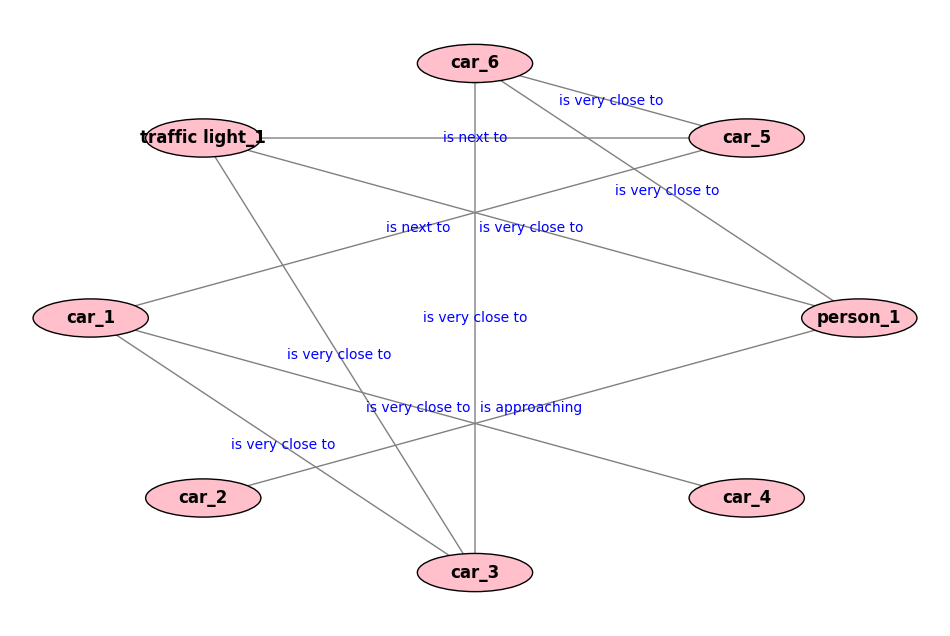

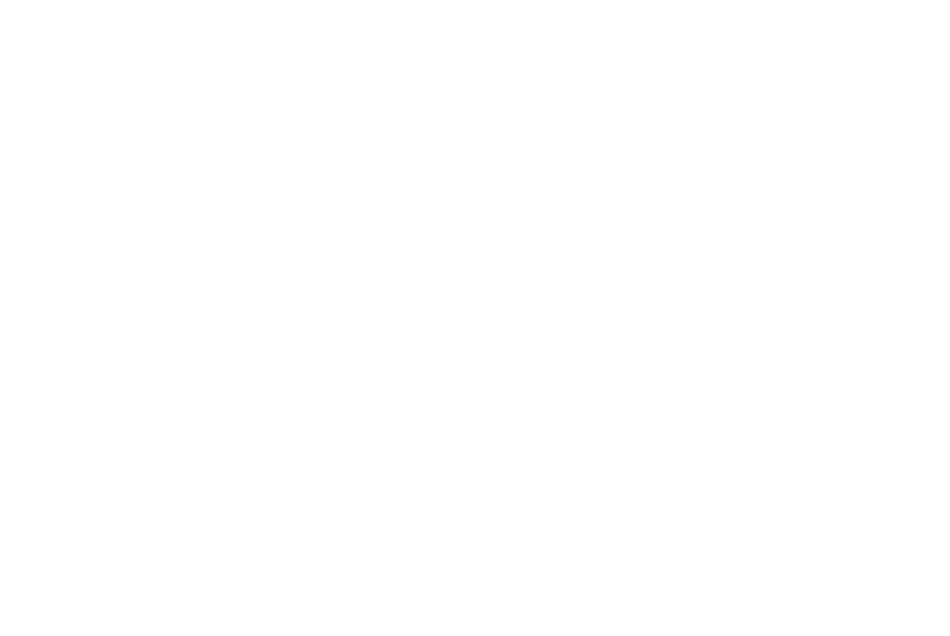

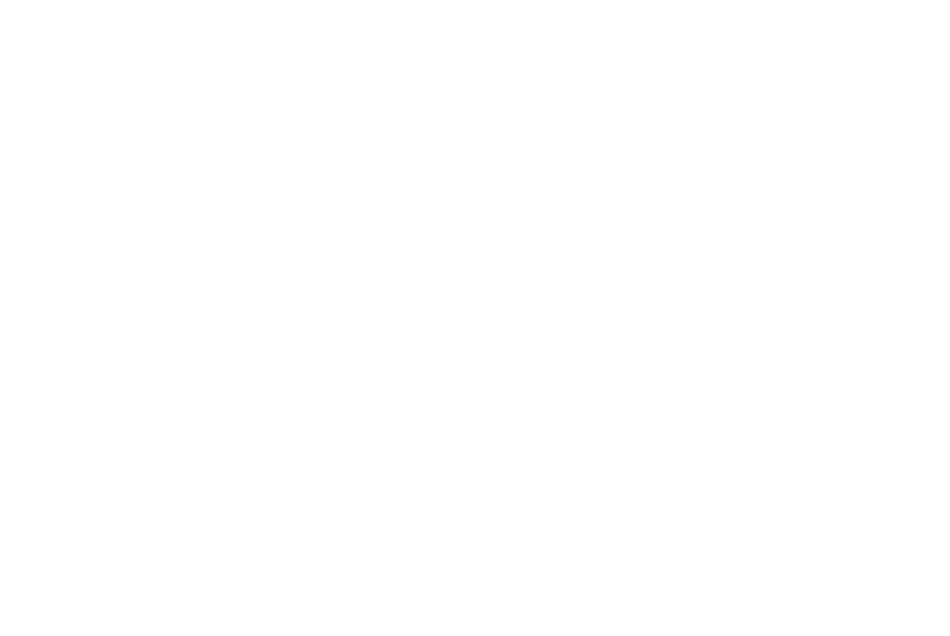

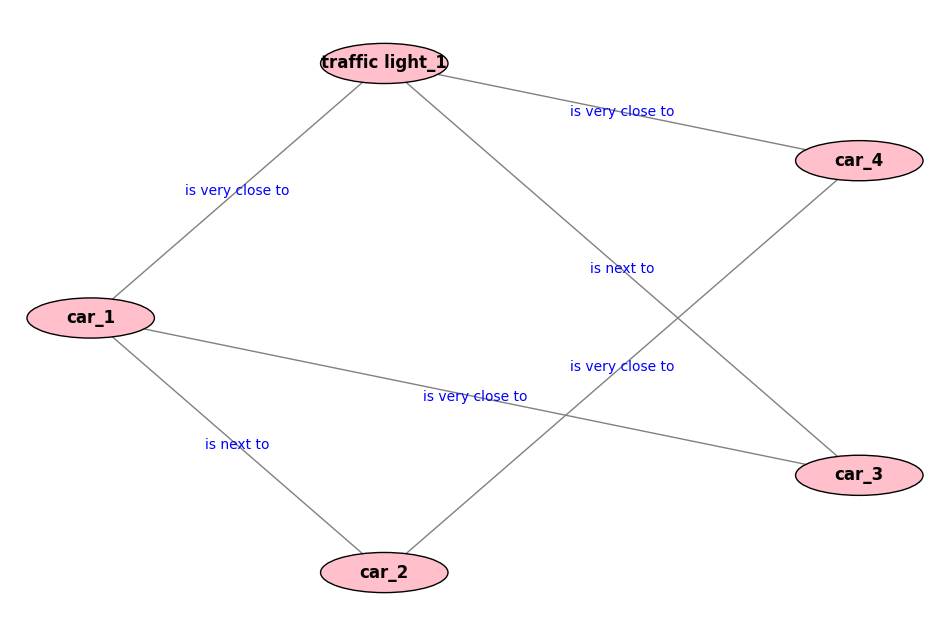

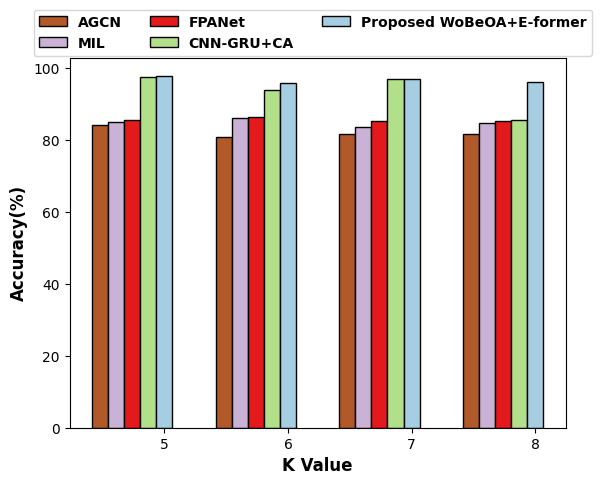

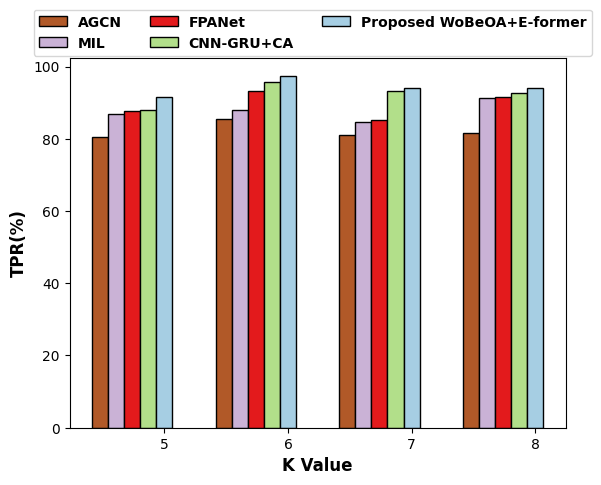

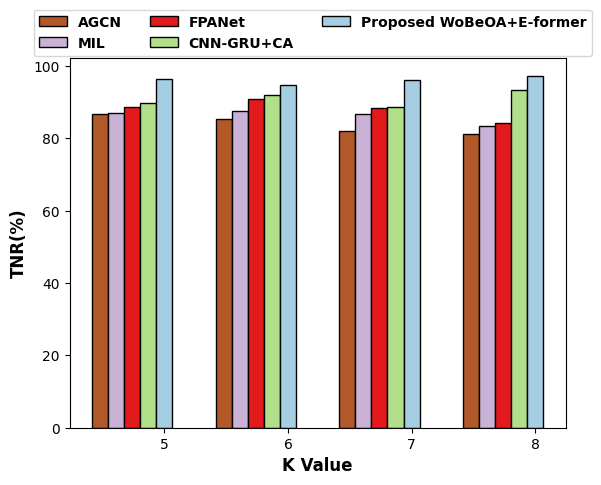

In [18]:
import csv
import numpy as np
import matplotlib.pyplot as plt
from mycolorpy import colorlist as mcp
from matplotlib import font_manager

def graphplpt_KFold(data,ylab):
    plt.figure()
    ax = plt.axes()

    #file="4"
    # with open(file+".csv", 'rt')as f:   #  4----5----6
    #     content = csv.reader(f)
    #     # Store data in array
    #     data = []
    #     for row in content:
    #         tem = []
    #         for j in row:
    #             tem.append((float(j)))  # attribute r from each row
    #         data.append(tem)
        #data = np.transpose(data)



    # to plot graph
    def plot_graph(result_1, result_2, result_3, result_4):
        loc, result = [], []
        result.append(result_1)  # appending the result
        result.append(result_2)
        result.append(result_3)
        result.append(result_4)


        result = np.transpose(result)

        # labels for bars
        labels=['AGCN','MIL','FPANet','CNN-GRU+CA','Proposed WoBeOA+E-former']

        tick_labels = [5,6,7,8]  # metrics with iteration = 20


        bar_width, s = 0.13, 0.0  # bar width, space between bars
        for i in range(len(result)):  # allocating location for bars
            if i is 0:  # initial location - 1st result
                tem = []
                for j in range(len(tick_labels)):
                    tem.append(j + 1)
                loc.append(tem)
            else:  # location from 2nd result
                tem = []
                for j in range(len(loc[i - 1])):
                    tem.append(loc[i - 1][j] + s + bar_width)
                loc.append(tem)
        palette = ['Accent', 'Accent_r', 'Dark2', 'Dark2_r', 'Paired', 'Paired_r', 'Pastel1', 'Pastel1_r', 'Pastel2',
                   'Pastel2_r', 'PiYG', 'PiYG_r', 'PuBu', 'PuBuGn', 'PuBuGn_r', 'PuBu_r', 'PuOr', 'PuOr_r', 'PuRd',
                   'PuRd_r', 'Purples', 'Purples_r', 'RdBu', 'RdBu_r', 'RdGy', 'RdGy_r', 'RdPu', 'RdPu_r', 'RdYlBu',
                   'RdYlBu_r', 'RdYlGn', 'RdYlGn_r', 'Reds', 'Reds_r', 'Set1', 'Set1_r', 'Set2', 'Set2_r', 'Set3', 'Set3_r',
                   'Spectral', 'Spectral_r', 'Wistia', 'Wistia_r', 'YlGn', 'YlGnBu', 'YlGnBu_r', 'YlGn_r', 'YlOrBr',
                   'YlOrBr_r', 'YlOrRd', 'YlOrRd_r', 'afmhot', 'afmhot_r', 'autumn', 'autumn_r', 'binary', 'binary_r',
                   'bone', 'bone_r', 'brg', 'brg_r', 'bwr', 'bwr_r', 'cividis', 'cividis_r', 'cool', 'cool_r', 'coolwarm',
                   'coolwarm_r', 'copper', 'copper_r', 'cubehelix', 'cubehelix_r', 'flag', 'flag_r', 'gist_earth',
                   'gist_earth_r', 'gist_gray', 'gist_gray_r', 'gist_heat', 'gist_heat_r', 'gist_ncar', 'gist_ncar_r',
                   'gist_rainbow', 'gist_rainbow_r', 'gist_stern', 'gist_stern_r', 'gist_yarg', 'gist_yarg_r', 'gnuplot',
                   'gnuplot2', 'gnuplot2_r', 'gnuplot_r', 'gray', 'gray_r', 'hot', 'hot_r', 'hsv', 'hsv_r', 'inferno',
                   'inferno_r', 'jet', 'jet_r', 'magma', 'magma_r', 'nipy_spectral', 'nipy_spectral_r', 'ocean', 'ocean_r',
                   'pink', 'pink_r', 'plasma', 'plasma_r', 'prism', 'prism_r', 'rainbow', 'rainbow_r', 'seismic',
                   'seismic_r', 'spring', 'spring_r', 'summer', 'summer_r', 'tab10', 'tab10_r', 'tab20', 'tab20_r',
                   'tab20b', 'tab20b_r', 'tab20c', 'tab20c_r', 'terrain', 'terrain_r', 'turbo', 'turbo_r', 'twilight',
                   'twilight_r', 'twilight_shifted', 'twilight_shifted_r', 'viridis', 'viridis_r', 'winter', 'winter_r']

        color1=mcp.gen_color(cmap=palette[5],n=5)

        # plotting a bar chart
        for i in range(len(result)):
            plt.bar(loc[i], result[i],label=labels[i], tick_label=tick_labels, edgecolor='black',color=color1[i],width=bar_width)       #,,label=labels[i],

        plt.legend()  # show a legend on the plot
        font = font_manager.FontProperties(family='Calibri',  # 'Times new roman',
                                           weight='bold',
                                           style='normal', size=10)
        plt.xlabel("K Value", fontweight='bold', size=12) #  K Value

        plt.ylabel(ylab, fontweight='bold', size=12) ####  Accuracy(%)  ,  TPR(%)  ,  TNR(%)
        plt.legend(loc='upper center', bbox_to_anchor=(0.49, 1.15),
                   fancybox=True, ncol=3, fontsize=10,prop=font)

        #plt.savefig(file+'.svg',dpi=900)
        #MMRE,MdMRE,Speed(s),RMSE,Pred,Model size,MAE,MSE,RMSE,Prediction error
    result_1, result_2, result_3, result_4= data[0], data[1], data[2], data[3]
    plot_graph(result_1, result_2, result_3, result_4)
    plt.show()
print('Running with K Value : 5')
k=5/10
ACC1,TPR1,TNR1=callmain(k)
k=6/10
print('Running with K Value : 6')
ACC2,TPR2,TNR2=callmain(k)
k=7/10
print('Running with K Value : 7')
ACC3,TPR3,TNR3=callmain(k)
k=8/10
print('Running with K Value : 8')
ACC4,TPR4,TNR4=callmain(k)

ACC=[ACC1,ACC2,ACC3,ACC4]
TPR=[TPR1,TPR2,TPR3,TPR4]
TNR=[TNR1,TNR2,TNR3,TNR4]

graphplpt_KFold(ACC,'Accuracy(%)')
graphplpt_KFold(TPR,'TPR(%)')
graphplpt_KFold(TNR,'TNR(%)')

**Ablation_study**

In [19]:
def Ablation_callmain(tr):
  ACC,TPR,TNR=[],[],[]

  Input_Img=read_image('Dataset/images/*/*')
  Audio_feature=pd.read_csv('Dataset/dataset.csv',nrows=1000)
  label=action_label(Audio_feature)
  ####################### Proposed WoBeOA+E-former  ######################
  classified_scene=Obj_seg_scene_classify_Eformer(Input_Img,tr,ACC,TPR,TNR)
  #####################   E-former #######################
  Obj_seg_scene_classify_Eformer_without_opt(Input_Img,tr,ACC,TPR,TNR)
  Idetified_action=VISFORMER_Action_Identify(Audio_feature,label,0.9)
  graph_construction(classified_scene,Idetified_action)

  return ACC,TPR,TNR

**Run below cell for Ablation result with Learning set(%)**

Running with Learning set : 60%
i : 0
i : 1
i : 2
i : 3
i : 4
i : 5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Running with Learning set : 70%
i : 0
i : 1
i : 2
i : 3
i : 4
i : 5
i : 6
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Running with Learning set : 80%
i : 0
i : 1
i : 2
i : 3
i : 4
i : 5
i : 6
i : 7
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Running with Learning set : 90%
i : 0
i : 1
i : 2
i : 3
i : 4
i : 5
i : 6
i : 7
i : 8
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


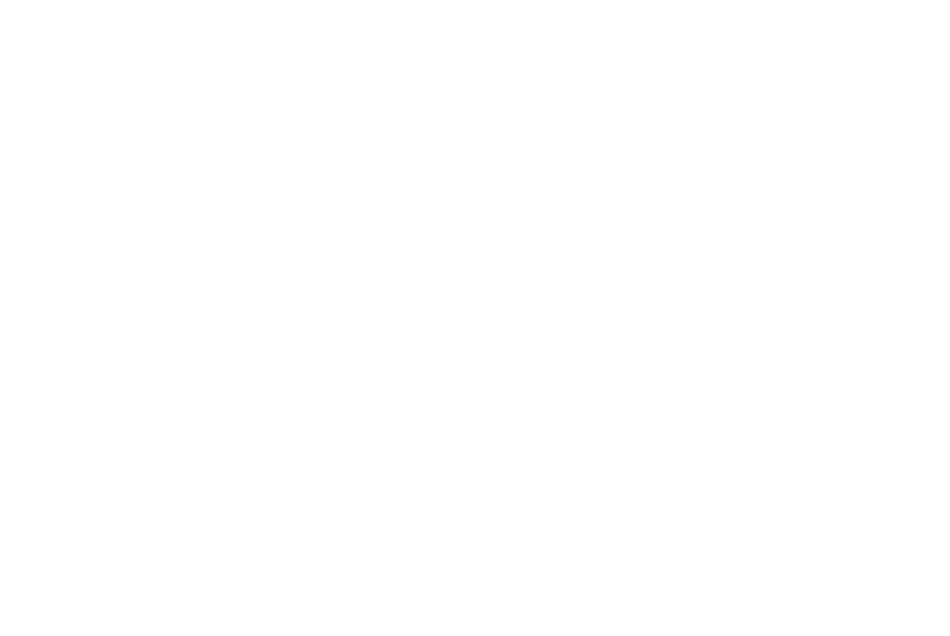

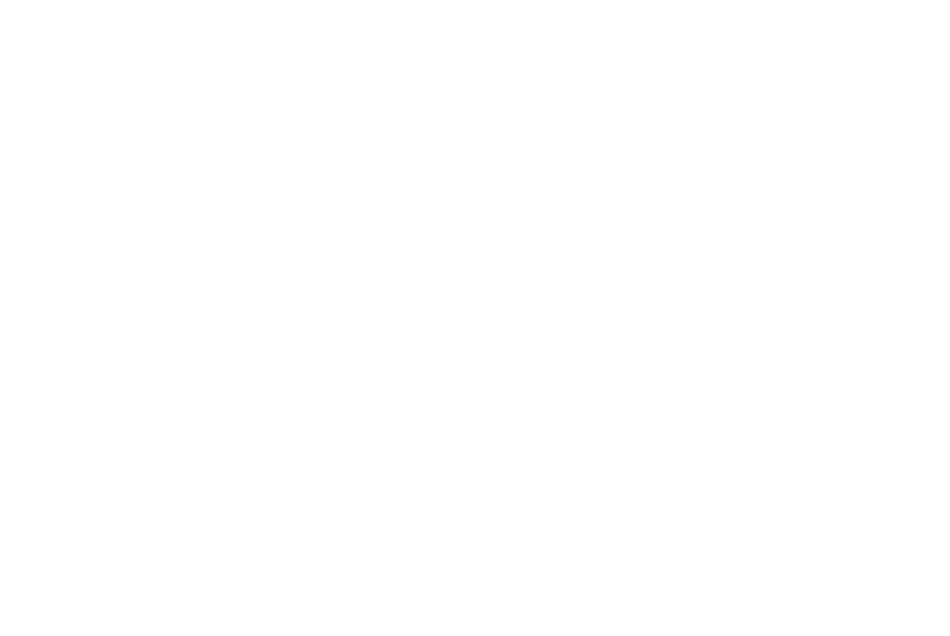

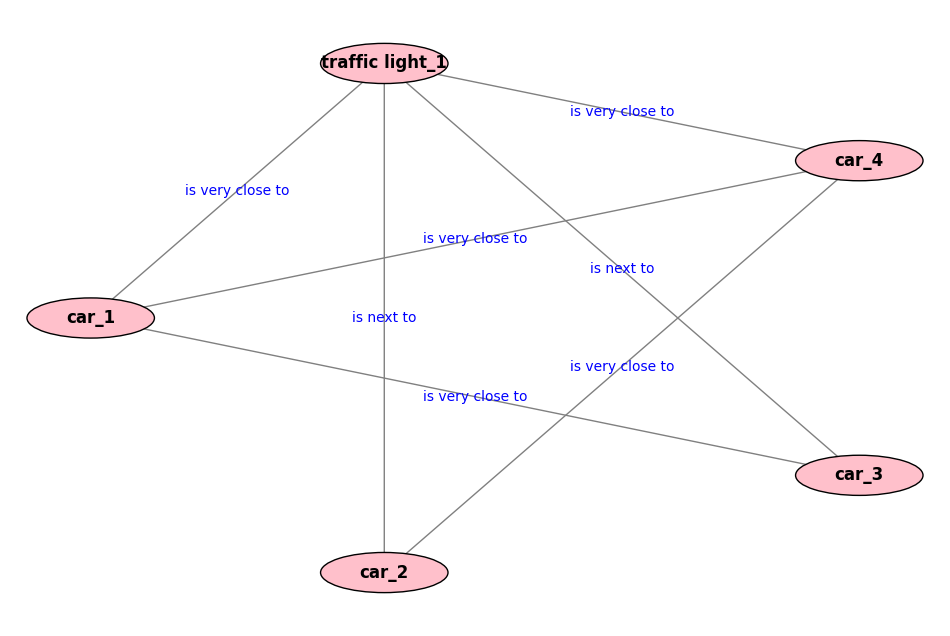

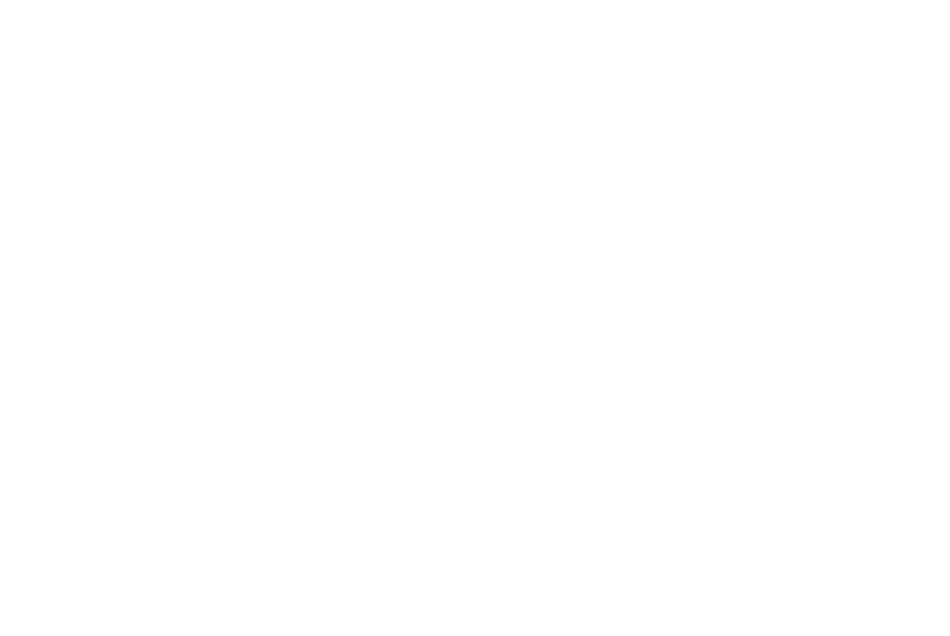

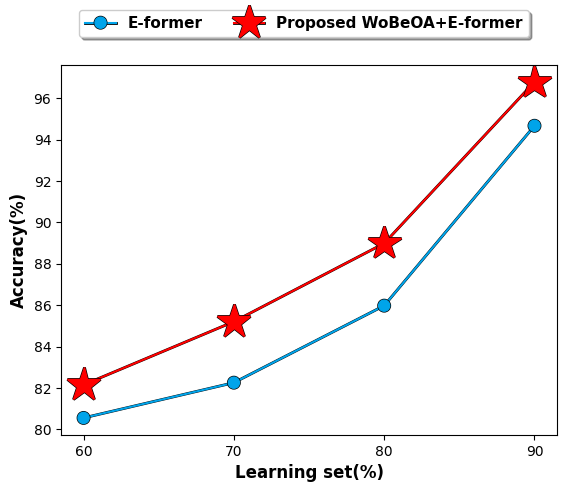

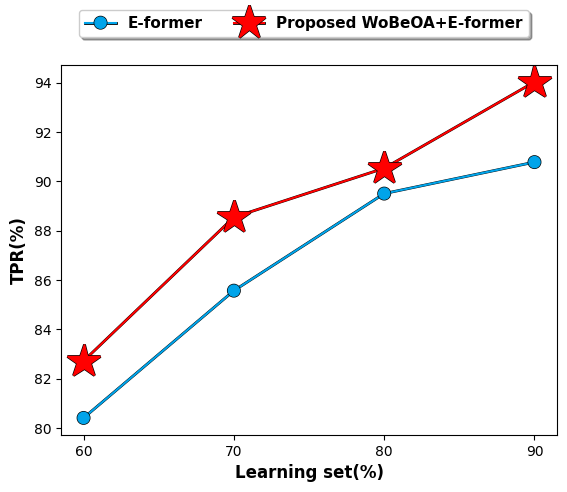

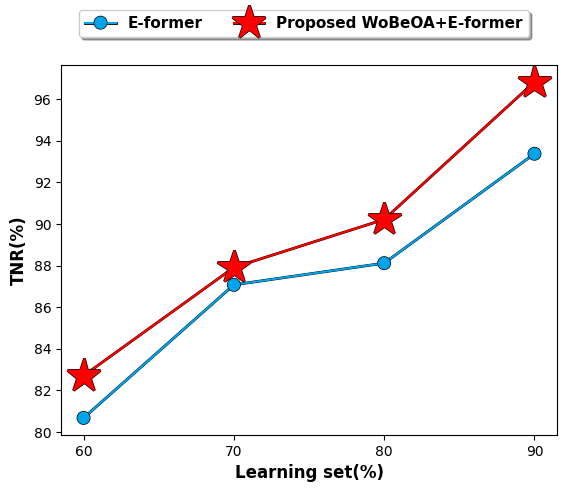

In [20]:
import matplotlib.pyplot as plt
from matplotlib import patheffects
from matplotlib import font_manager
import pandas as pd
import numpy as np
def arr(data):
    for i in range(len(data)):
        data[i] = random.uniform(80, 98)
    data.sort()
    return data
def Ablation_Learningset(data,ylab):
    #file='1'  # 1---2---3
    #data = pd.read_csv(file+".csv", header=None)
    data=np.array(data).flatten()
    arr(data)
    #data.flatten()
    data=[data[0:2],data[2:4],data[4:6],data[6:8]]
    data=np.array(data)

    plt.figure()
    xlabel=["60","70","80","90"]
    colour = ["#00A4EA","red"]   # Colour
    marker = [ 'o', '*']
    for k in range(len(data[0])):
        mark = 8
        if k == len(data[0]) - 1:
            mark = 25
        plt.plot(xlabel,data[:,k],linestyle='-',markersize=mark,path_effects=[patheffects.Stroke(linewidth=2, foreground='black'), patheffects.Normal()],marker=marker[k],color=colour[k])
    font = font_manager.FontProperties(family='Calibri',  # 'Times new roman',
                                           weight='bold',
                                           style='normal', size=11)

    legends=['E-former','Proposed WoBeOA+E-former']
    plt.xlabel("Learning set(%)", fontweight='bold', size=12)  # Learning set(%)
    plt.ylabel(ylab, fontweight='bold', size=12)  # Accuracy(%)  , TPR(%)  , TNR(%)
    plt.legend(legends, loc='upper center', bbox_to_anchor=(0.49, 1.17),
               ncol=3, fancybox=True, shadow=True, fontsize=9.5,prop=font)
    #plt.savefig(file +'.svg',dpi=900)
    plt.show()

print('Running with Learning set : 60%')
ACC1,TPR1,TNR1=Ablation_callmain(0.6)
print('Running with Learning set : 70%')
ACC2,TPR2,TNR2=Ablation_callmain(0.7)
print('Running with Learning set : 80%')
ACC3,TPR3,TNR3=Ablation_callmain(0.8)
print('Running with Learning set : 90%')
ACC4,TPR4,TNR4=Ablation_callmain(0.9)

ACC=[ACC1,ACC2,ACC3,ACC4]
TPR=[TPR1,TPR2,TPR3,TPR4]
TNR=[TNR1,TNR2,TNR3,TNR4]

Ablation_Learningset(ACC,'Accuracy(%)')
Ablation_Learningset(TPR,'TPR(%)')
Ablation_Learningset(TNR,'TNR(%)')


**Run below cell for Ablation K Value**

<>:39: SyntaxWarning: "is" with a literal. Did you mean "=="?
<>:39: SyntaxWarning: "is" with a literal. Did you mean "=="?
/tmp/ipython-input-3334647847.py:39: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if i is 0:  # initial location - 1st result


Running with K Value : 5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Running with K Value : 6
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Running with K Value : 7
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Running with K Value : 8
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
>>>>>>>>>>... [[82.03526211 82.20756564]
 [82.606156   86.55004345]
 [89.25879865 93.93790269]
 [95.78232456 97.75186705]]


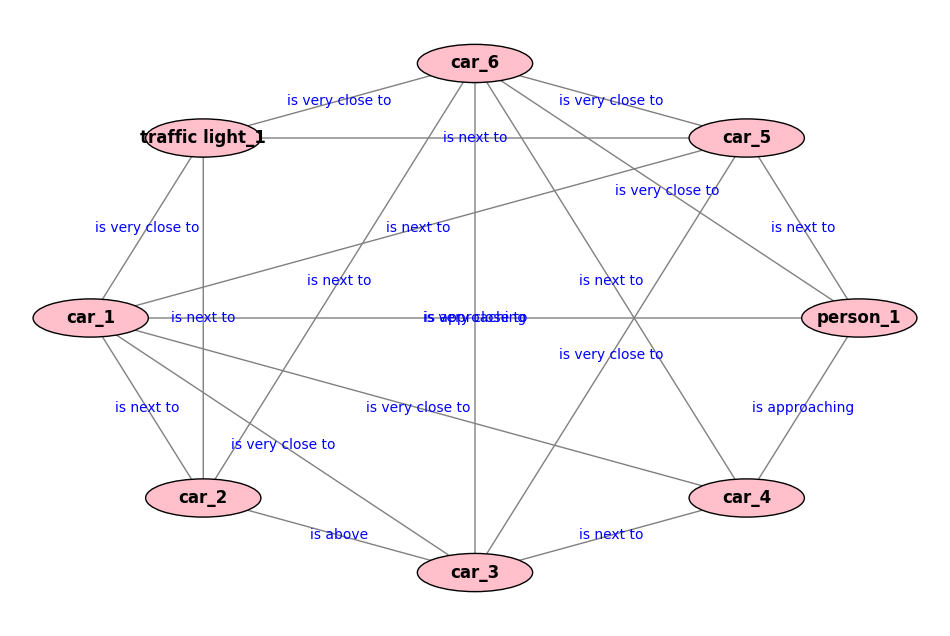

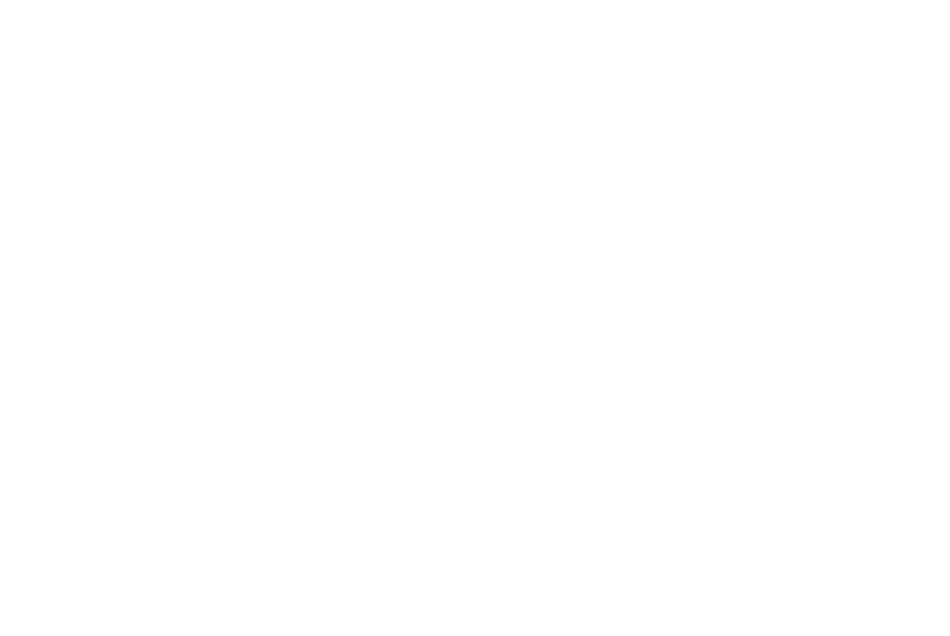

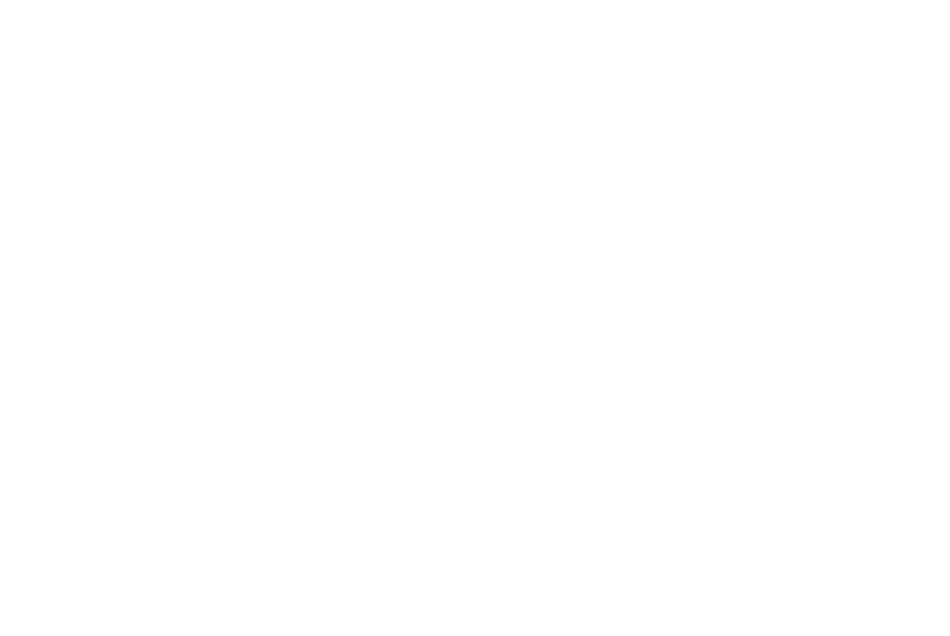

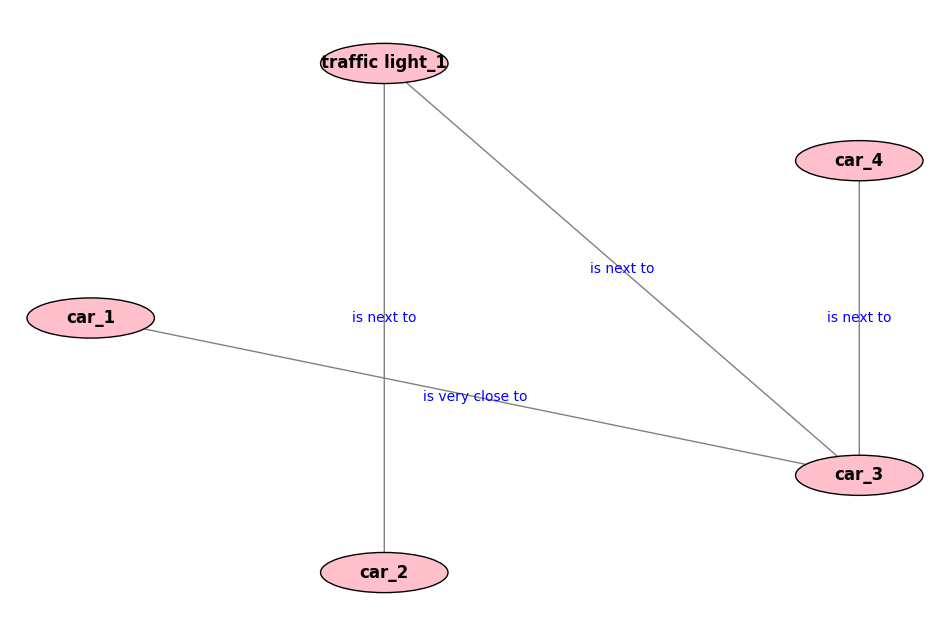

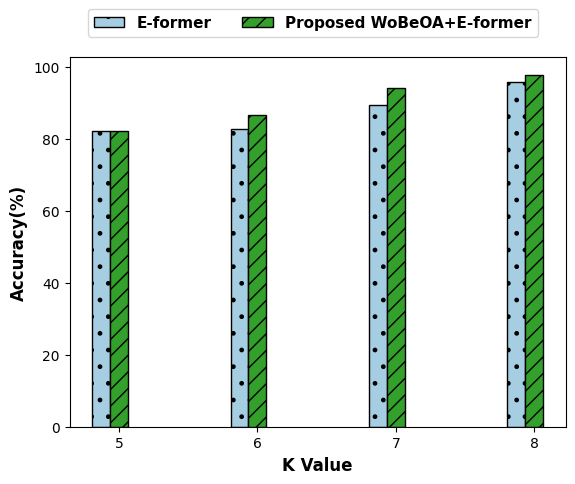

>>>>>>>>>>... [[80.05629349 80.65316418]
 [80.9205102  82.85872769]
 [84.04518528 93.22848371]
 [94.71359697 95.06588443]]


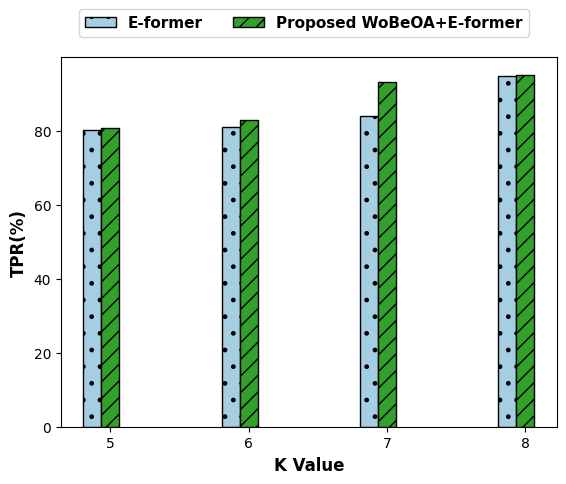

>>>>>>>>>>... [[82.11377929 86.97127101]
 [88.88892576 89.75475234]
 [91.07341209 93.54889551]
 [94.86946813 97.46454148]]


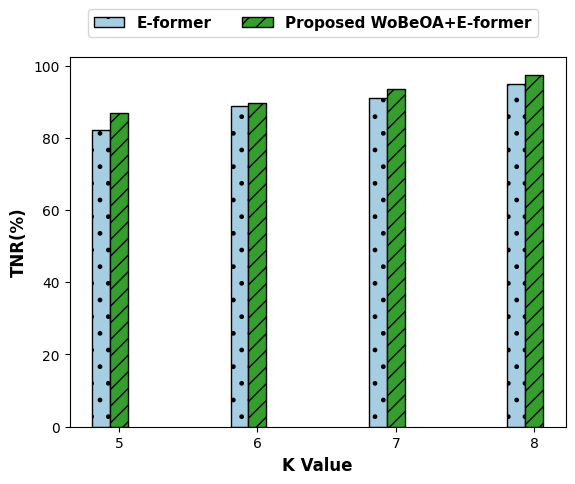

In [23]:
import csv
import numpy as np
import matplotlib.pyplot as plt
from mycolorpy import colorlist as mcp
from matplotlib import font_manager
def arr(data):
    for i in range(len(data)):
        data[i] = random.uniform(80, 98)
    data.sort()
    return data
def Ablation_KValue(data,ylab):
    data=np.array(data).flatten()
    arr(data)

    data=[data[0:2],data[2:4],data[4:6],data[6:8]]
    data=np.array(data)
    plt.figure()
    ax = plt.axes()


    # to plot graph
    def plot_graph(result_1, result_2, result_3, result_4):
        loc, result = [], []
        result.append(result_1)  # appending the result
        result.append(result_2)
        result.append(result_3)
        result.append(result_4)


        result = np.transpose(result)

        # labels for bars
        labels=['E-former','Proposed WoBeOA+E-former']

        tick_labels = [5,6,7,8] # metrics with iteration = 20

        bar_width, s = 0.13, 0.0  # bar width, space between bars
        for i in range(len(result)):  # allocating location for bars
            if i is 0:  # initial location - 1st result
                tem = []
                for j in range(len(tick_labels)):
                    tem.append(j + 1)
                loc.append(tem)
            else:  # location from 2nd result
                tem = []
                for j in range(len(loc[i - 1])):
                    tem.append(loc[i - 1][j] + s + bar_width)
                loc.append(tem)
        palette = ['Accent', 'Accent_r', 'Dark2', 'Dark2_r', 'Paired', 'Paired_r', 'Pastel1', 'Pastel1_r', 'Pastel2',
                   'Pastel2_r', 'PiYG', 'PiYG_r', 'PuBu', 'PuBuGn', 'PuBuGn_r', 'PuBu_r', 'PuOr', 'PuOr_r', 'PuRd',
                   'PuRd_r', 'Purples', 'Purples_r', 'RdBu', 'RdBu_r', 'RdGy', 'RdGy_r', 'RdPu', 'RdPu_r', 'RdYlBu',
                   'RdYlBu_r', 'RdYlGn', 'RdYlGn_r', 'Reds', 'Reds_r', 'Set1', 'Set1_r', 'Set2', 'Set2_r', 'Set3', 'Set3_r',
                   'Spectral', 'Spectral_r', 'Wistia', 'Wistia_r', 'YlGn', 'YlGnBu', 'YlGnBu_r', 'YlGn_r', 'YlOrBr',
                   'YlOrBr_r', 'YlOrRd', 'YlOrRd_r', 'afmhot', 'afmhot_r', 'autumn', 'autumn_r', 'binary', 'binary_r',
                   'bone', 'bone_r', 'brg', 'brg_r', 'bwr', 'bwr_r', 'cividis', 'cividis_r', 'cool', 'cool_r', 'coolwarm',
                   'coolwarm_r', 'copper', 'copper_r', 'cubehelix', 'cubehelix_r', 'flag', 'flag_r', 'gist_earth',
                   'gist_earth_r', 'gist_gray', 'gist_gray_r', 'gist_heat', 'gist_heat_r', 'gist_ncar', 'gist_ncar_r',
                   'gist_rainbow', 'gist_rainbow_r', 'gist_stern', 'gist_stern_r', 'gist_yarg', 'gist_yarg_r', 'gnuplot',
                   'gnuplot2', 'gnuplot2_r', 'gnuplot_r', 'gray', 'gray_r', 'hot', 'hot_r', 'hsv', 'hsv_r', 'inferno',
                   'inferno_r', 'jet', 'jet_r', 'magma', 'magma_r', 'nipy_spectral', 'nipy_spectral_r', 'ocean', 'ocean_r',
                   'pink', 'pink_r', 'plasma', 'plasma_r', 'prism', 'prism_r', 'rainbow', 'rainbow_r', 'seismic',
                   'seismic_r', 'spring', 'spring_r', 'summer', 'summer_r', 'tab10', 'tab10_r', 'tab20', 'tab20_r',
                   'tab20b', 'tab20b_r', 'tab20c', 'tab20c_r', 'terrain', 'terrain_r', 'turbo', 'turbo_r', 'twilight',
                   'twilight_r', 'twilight_shifted', 'twilight_shifted_r', 'viridis', 'viridis_r', 'winter', 'winter_r']

        color1=mcp.gen_color(cmap=palette[4],n=5)
        hatchh=[".","//","x","+","o","*"]
        opacity=1
        # plotting a bar chart
        for i in range(len(result)):
            plt.bar(loc[i], result[i],label=labels[i], tick_label=tick_labels, edgecolor='black',color=color1[i],width=bar_width,alpha=opacity,hatch=hatchh[i])       #,,label=labels[i],

        plt.legend()  # show a legend on the plot
        font = font_manager.FontProperties(family='Calibri',  # 'Times new roman',
                                           weight='bold',
                                           style='normal', size=11)
        plt.xlabel("K Value", fontweight='bold', size=12)# K Value

        plt.ylabel(ylab, fontweight='bold', size=12) ####  Accuracy(%)  , TPR(%)  , TNR(%)
        plt.legend(loc='upper center', bbox_to_anchor=(0.49, 1.15),
                   fancybox=True, ncol=3, fontsize=10,prop=font)

        #plt.savefig(file+'.svg',dpi=900)
        #MMRE,MdMRE,Speed(s),RMSE,Pred,Model size,MAE,MSE,RMSE,Prediction error
    result_1, result_2, result_3, result_4= data[0], data[1], data[2], data[3]
    plot_graph(result_1, result_2, result_3, result_4)
    plt.show()

print('Running with K Value : 5')
k=5/10
ACC1,TPR1,TNR1=Ablation_callmain(k)
k=6/10
print('Running with K Value : 6')
ACC2,TPR2,TNR2=Ablation_callmain(k)
k=7/10
print('Running with K Value : 7')
ACC3,TPR3,TNR3=Ablation_callmain(k)
k=8/10
print('Running with K Value : 8')
ACC4,TPR4,TNR4=Ablation_callmain(k)

ACC=[ACC1,ACC2,ACC3,ACC4]
TPR=[TPR1,TPR2,TPR3,TPR4]
TNR=[TNR1,TNR2,TNR3,TNR4]

Ablation_KValue(ACC,'Accuracy(%)')
Ablation_KValue(TPR,'TPR(%)')
Ablation_KValue(TNR,'TNR(%)')

**Demo code**

model_final_a3ec72.pkl: 254MB [00:01, 197MB/s]                           
/usr/local/lib/python3.11/dist-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


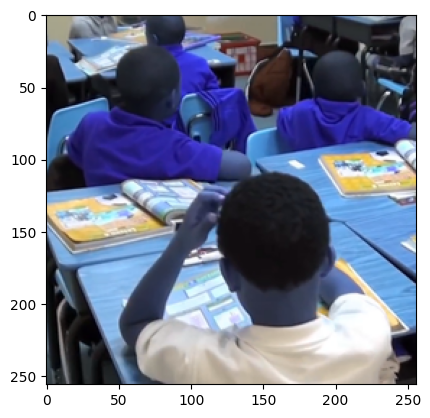

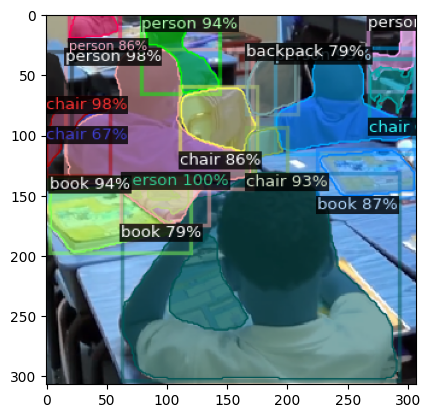

<Figure size 640x480 with 0 Axes>

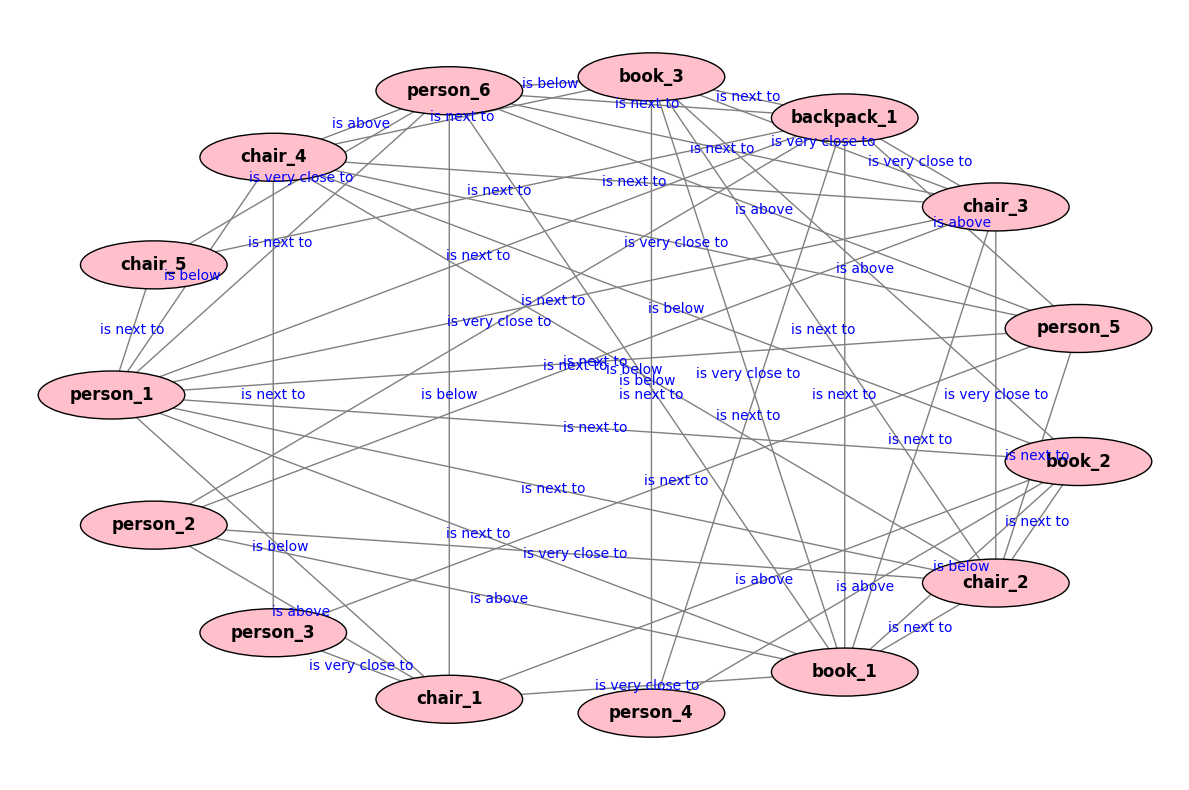

In [16]:
import cv2
import torch
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from collections import defaultdict
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2 import model_zoo
from detectron2.data import MetadataCatalog
from PIL import Image
import random
import pandas as pd
# Load Detectron2 configuration and model
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_101_FPN_3x.yaml"))
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.6
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_101_FPN_3x.yaml")
cfg.MODEL.DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
predictor = DefaultPredictor(cfg)
class_names = MetadataCatalog.get(cfg.DATASETS.TRAIN[0]).thing_classes
plt.figure()
path='Dataset/images/classroom1/'
# Load image
image_path = path+"classroom2.png"  # Replace with your Image path  for More Result
image_cv = cv2.imread(image_path)
plt.imshow(image_cv)
image_pil = Image.open(image_path).convert("RGB")
# Load Audio features
Audio_fea=pd.read_csv('Dataset/dataset.csv')


################################## Object segmentation and scene classification using EFormer ###############
plt.figure()
# Run detection
outputs = predictor(image_cv)
instances = outputs["instances"].to("cpu")
boxes = instances.pred_boxes.tensor.numpy()
labels = instances.pred_classes.numpy()

v = Visualizer(image_cv[:, :, ::-1], MetadataCatalog.get(cfg.DATASETS.TRAIN[0]), scale=1.2)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
out=out.get_image()[:, :, ::-1]
plt.imshow(out)
plt.figure()
# o.imwrite(path+'2-object_seg_and_scene_classfiy.jpg',out)
# Assign unique labels with label counts (person_1, person_2, etc.)
label_counts = defaultdict(int)
node_labels = []
G = nx.DiGraph()

for i, (box, label) in enumerate(zip(boxes, labels)):
    label_name = class_names[label]
    label_counts[label_name] += 1
    unique_label = f"{label_name}_{label_counts[label_name]}"
    node_labels.append(unique_label)
    G.add_node(i, label=unique_label, bbox=box)

# Improved heuristic-based relationship inference
def infer_relation(labelA, labelB, boxA, boxB):
    xa, ya = (boxA[0] + boxA[2]) / 2, (boxA[1] + boxA[3]) / 2
    xb, yb = (boxB[0] + boxB[2]) / 2, (boxB[1] + boxB[3]) / 2
    dx, dy = abs(xa - xb), abs(ya - yb)

    if "person" in labelA and "frisbee" in labelB and dy < 80 and dx < 100:
        return "is catching"
    elif "dog" in labelA and ("sofa" in labelB or "couch" in labelB) and dy < 100:
        return "is resting on"
    elif "person" in labelA and "bicycle" in labelB and dy < 120:
        return "is riding"
    elif "car" in labelA and "person" in labelB and dx < 150:
        return "is approaching"
    elif "person" in labelA and "dog" in labelB and dx < 100:
        return "is standing beside"
    elif dx < 60 and dy < 60:
        return "is very close to"
    elif dx < 120:
        return "is next to"
    elif ya < yb:
        return "is above"
    else:
        return "is below"
#-----------  Graph construction-------------------
# Add edges based on improved heuristic, limiting to relevant pairs only
for i in range(len(boxes)):
    for j in range(i + 1, len(boxes)):
        if random.random() > 0.5:  # Randomly skip some edges to keep graph meaningful
            continue
        labelA = node_labels[i]
        labelB = node_labels[j]
        rel = infer_relation(labelA, labelB, boxes[i], boxes[j])
        G.add_edge(i, j, relation=rel)

# Visualize the scene graph with oval-shaped nodes using annotations
plt.figure(figsize=(12, 8))
pos = nx.shell_layout(G)
edge_labels = nx.get_edge_attributes(G, 'relation')
nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True)

ax = plt.gca()
ax.set_axis_off()

for node, (x, y) in pos.items():
    label = G.nodes[node]['label']
    ellipse = Ellipse((x, y), width=0.3, height=0.15, edgecolor='black', facecolor='pink', zorder=2)
    ax.add_patch(ellipse)
    ax.text(x, y, label, horizontalalignment='center', verticalalignment='center',fontweight='bold', fontsize=12, zorder=3)

for (u, v), label in edge_labels.items():
    x1, y1 = pos[u]
    x2, y2 = pos[v]
    xm, ym = (x1 + x2) / 2, (y1 + y2) / 2
    ax.text(xm, ym, label, fontsize=10, color='blue', ha='center', va='center')
#plt.savefig(path+'3-scene graph.jpg',dpi=300)
plt.tight_layout()
plt.show()